# ADD PALLATE CLEANSER

# init

In [ ]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
!pip install skorch
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping
import pickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
db = pd.read_csv("database2.csv")
db = pd.concat([pd.read_csv("database25.csv"), db]).drop("Unnamed: 0", axis = 1)

In [ ]:
db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
for col in ["eFG", "ORB_pct", "TOV_pct", "FT_FGA"]:
    db_used[f"net_{col}_team1"] = db[f"{col}_team1"] - db[f"opp_{col}_team2"]
    db_used[f"net_{col}_team2"] = db[f"{col}_team2"] - db[f"opp_{col}_team1"]
    db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]
# db_used["net_rtg_diff"] = (db["off_rtg_team1"] - db["def_rtg_team1"]) - (db["off_rtg_team2"] - db["def_rtg_team2"])
# db_used["net_eFG"] = db["eFG_team1"] - db["opp_eFG_team2"]
# db_used["net_TOV_pct"] = db["TOV_pct_team1"] - db["opp_TOV_pct_team2"]
# db_used["net_ORB_pct"] = db["ORB_pct_team1"] -
# db_used

# # for augmented section
mirrored = -db_used.iloc[:,:-12].copy()
for col in ["eFG", "ORB_pct", "TOV_pct", "FT_FGA"]:
    mirrored[f"net_{col}_team1"] = db[f"{col}_team2"] - db[f"opp_{col}_team1"]
    mirrored[f"net_{col}_team2"] = db[f"{col}_team1"] - db[f"opp_{col}_team2"]
    mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]
# mirrored["net_rtg_diff"] = (db["off_rtg_team2"] - db["def_rtg_team2"]) - (db["off_rtg_team1"] - db["def_rtg_team1"])
# mirrored["net_eFG"] = db["eFG_team2"] - db["opp_eFG_team1"]
# mirrored["net_TOV_pct"] = db["TOV_pct_team2"] - db["opp_TOV_pct_team1"]
# mirrored

In [ ]:
db_used = db_used.loc[:,list(c for c in db_used.columns if not any(s in c for s in {"team2", "spread","net_rtg"}))]
mirrored = mirrored.loc[:,list(c for c in mirrored.columns if not any(s in c for s in {"team2", "spread","net_rtg"}))]

In [ ]:
not_included: set[str] = {"season","round","team1","team2","team1_seed","team2_seed","win"}
# X = db.loc[:,list(c for c in db.columns if c not in not_included)]
y = np.array(db["win"]).reshape(-1,1)

X = np.vstack([np.array(db_used), np.array(mirrored)])

# augmenting diffs
y = np.vstack([y, 1 - y])

# y = np.vstack([y.reshape(-1,1), y.reshape(-1,1)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 0)
# X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size = .5, random_state = 0)


# scaler = StandardScaler()

with open('standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# X_valid_scaled = scaler.transform(X_valid)

X_train = torch.as_tensor(X_train, dtype = torch.float32)
X_test = torch.as_tensor(X_test, dtype = torch.float32)
# X_valid = torch.as_tensor(X_valid, dtype = torch.float32)

X_train_scaled = torch.as_tensor(X_train_scaled, dtype = torch.float32)
X_test_scaled = torch.as_tensor(X_test_scaled, dtype = torch.float32)
# X_valid_scaled = torch.as_tensor(X_valid_scaled, dtype = torch.float32)

# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)
# y_valid = torch.tensor(y_valid, dtype = torch.float32)

In [ ]:
import pickle

# Save the scaler to a file in binary write mode ('wb')
with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [ ]:
from torch.utils.data import DataLoader

bs: int = 35

class BatchLoader(DataLoader):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

training_data = BatchLoader(X_train, y_train)
valid_data = BatchLoader(X_test, y_test)
train_dataloader = DataLoader(training_data, batch_size=bs, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=bs, shuffle=True)

In [ ]:
def error_measures(y_pred, y_true, thresh = .5, roc: bool = False):

    n: int = y_pred.shape[0]
    # acc: float = sum(torch.round(y_pred) == y_true).item()/n

    y_pred = y_pred > thresh

    measures: dict[str, int] = {
        "TP" : 0, "TN" : 0,
        "FP" : 0,  "FN" : 0
    }

    for i in range(n):
        if y_pred[i] + y_true[i] == 2:
            measures["TP"] += 1
        elif y_pred[i] + y_true[i] == 0:
            measures["TN"] += 1
        elif y_pred[i] == 1:
            measures["FP"] += 1
        else:
            measures["FN"] += 1

    if roc:
        return measures["TP"]/(measures["TP"] + measures["FN"]), measures["FP"]/(measures["FP"] + measures["TN"])
    else:
        acc: float = (measures["TP"] + measures["TN"])/n
        tpr: float = measures["TP"]/(measures["TP"] + measures["FN"])
        fpr: float = measures["FP"]/(measures["FP"] + measures["TN"])
        prec: float = measures["TP"]/(measures["FP"] + measures["TP"])
        print(f"""
        Accuracy: {(measures["TP"] + measures["TN"])/n}
        TPR: {measures["TP"]/(measures["TP"] + measures["FN"])}
        FPR: {measures["FP"]/(measures["FP"] + measures["TN"])}
        Precision: {measures["TP"]/(measures["FP"] + measures["TP"])}
        """)
        return acc, tpr, fpr, prec

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int , output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        # return self.sigmoid(x)
        return x

## using skorch

In [ ]:
from skorch import NeuralNetClassifier
from sklearn.model_selection import RandomizedSearchCV
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

net = NeuralNetClassifier(
    module=Model,
    module__input_size=X_train.shape[1],
    criterion=torch.nn.BCEWithLogitsLoss,
    optimizer=torch.optim.Adam,
    max_epochs=250,
    verbose=0, # Set to 0 to keep the output clean during search
    callbacks=[EarlyStopping(patience=20, monitor='valid_loss')], # Early Stopping
    train_split=ValidSplit(cv=5) # Required for EarlyStopping to have a validation set
)

params = {
    'lr': [.00005, .0001, .0002, .0005, .001, .002, .004, .005, .01, .025, .05, .1],        # Learning Rate
    'module__n_layers': np.arange(1, 5),                  # Number of Layers
    'module__hidden_dim': [8, 16, 32, 64, 128],          # Hidden Size
    'module__dropout': np.arange(1,1000)/1000,                # Dropout Value
    'optimizer__weight_decay': [0, .0001, .0005, .001, .002, .005, .01, .02, .05, .1, .25], # Lambda (L2 Regularization)
}

rs = RandomizedSearchCV(net, params, n_iter=250, cv=5, scoring='neg_log_loss', n_jobs = -1)
rs.fit(X_train_scaled, y_train) # X, y as numpy arrays or torch tensors

RandomizedSearchCV(cv=5,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__input_size'}, batch_size=128, callbacks=[<skorch.callbacks.training.EarlyStopping object at 0x7eeaee69ef30>], compile=False, criterion=<class 'torch.nn.modules.loss.BCEWithLogitsLoss'>, dataset=<class 'skorch.dataset.Dataset'>, device='cpu', iterator_train=<class 'torch.utils.da...
       0.964, 0.965, 0.966, 0.967, 0.968, 0.969, 0.97 , 0.971, 0.972,
       0.973, 0.974, 0.975, 0.976, 0.977, 0.978, 0.979, 0.98 , 0.981,
       0.982, 0.983, 0.984, 0.985, 0.986, 0.987, 0.988, 0.989, 0.99 ,
       0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999]),
                                        'module__hidden_dim': [8, 16, 32, 64,
                                                               128],
                                        'module__n_layers': array([1, 2, 3, 4]),
                                        'optimizer__weight_decay': [0, 0.0001,
                                                                    0.0005,
                                                                    0.001,
                                                                    0.002,
                                                                    0.005, 0.01,
                                                                    0.02, 0.05,
                                                                    0.1,
                                                                    0.25]},
                   scoring='neg_log_loss')

In [ ]:
# ran 250 iterations, 5 cv in 51 minuted
rs.best_estimator_

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Model(
    (layers): ModuleList(
      (0): Linear(in_features=23, out_features=64, bias=False)
      (1): Linear(in_features=64, out_features=64, bias=False)
    )
    (bn_layers): ModuleList(
      (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (dropout): Dropout(p=0.522, inplace=False)
    (output_layer): Linear(in_features=64, out_features=1, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  ),
)

In [ ]:
rs.best_estimator_.optimizer__weight_decay, rs.best_estimator_.lr

(0.02, 0.002)

In [ ]:
rs.best_estimator_

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Model(
    (layers): ModuleList(
      (0): Linear(in_features=23, out_features=64, bias=False)
      (1): Linear(in_features=64, out_features=64, bias=False)
    )
    (bn_layers): ModuleList(
      (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (dropout): Dropout(p=0.522, inplace=False)
    (output_layer): Linear(in_features=64, out_features=1, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  ),
)

In [ ]:
nn = rs.best_estimator_

In [ ]:
from skorch import NeuralNetClassifier

In [ ]:
with open(f'nn_23.pkl', 'wb') as f:
    pickle.dump(nn, f)
# files.download(f"nn_23.pkl")

PicklingError: Can't pickle <class '__main__.Model'>: it's not the same object as __main__.Model

In [ ]:
rs.best_params_

{'optimizer__weight_decay': 0.02,
 'module__n_layers': np.int64(1),
 'module__hidden_dim': 64,
 'module__dropout': np.float64(0.522),
 'lr': 0.002}

In [ ]:
y_pred = nn.predict_proba(X_test_scaled)[:,-1,0]
error_measures(y_pred, y_test.numpy())
np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))


        Accuracy: 0.7947845804988662
        TPR: 0.8113207547169812
        FPR: 0.2205240174672489
        Precision: 0.7730337078651686
        


np.float32(-0.45990476)

## manual

In [ ]:
hyperparameters = pd.DataFrame(columns = ["train_loss", "test_loss", "hidden_layers", "lr", "lambda", "epochs", "augmented", "features","dropout","dropout_val", "hidden_size","batchnorm", "early_stopping", "best_test_loss"])

Epoch 25:
Train:

        Accuracy: 0.7554925584691708
        TPR: 0.7163531114327062
        FPR: 0.20694444444444443
        Precision: 0.7686335403726708
        
Test:

        Accuracy: 0.7450424929178471
        TPR: 0.6858638743455497
        FPR: 0.18518518518518517
        Precision: 0.8136645962732919
        
Epoch 50:
Train:

        Accuracy: 0.7703756201275691
        TPR: 0.7872648335745297
        FPR: 0.24583333333333332
        Precision: 0.7545076282940361
        
Test:

        Accuracy: 0.7252124645892352
        TPR: 0.7225130890052356
        FPR: 0.2716049382716049
        Precision: 0.7582417582417582
        
Epoch 75:
Train:

        Accuracy: 0.778880226789511
        TPR: 0.7539797395079595
        FPR: 0.19722222222222222
        Precision: 0.7858220211161387
        
Test:

        Accuracy: 0.7195467422096318
        TPR: 0.6858638743455497
        FPR: 0.24074074074074073
        Precision: 0.7705882352941177
        
Epoch 100:
Train:

        Accura

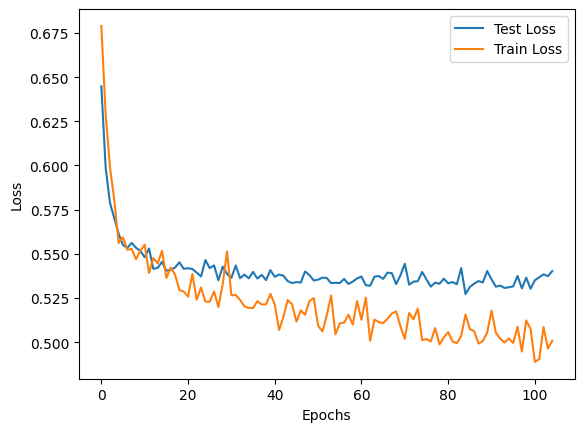

In [ ]:
torch.manual_seed(0)

dropout: int = 1
dropout_val: float = .3
augmented: int = 1
hidden: int = 2
hidden_size: int = 32
batch_norm: int = 1
early_stopping: int = 1
model = Model(X_train.shape[1], n_layers = hidden, hidden_dim=hidden_size, dropout = dropout_val)

patience: int = 20
wait: int = 0
best_loss: float = float("inf")
best_model_state = None

loss_fn = torch.nn.BCELoss()

lr = 0.001
lamb = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = lamb)

epochs: int = 250

train_loss: list[float] = list()
test_loss: list[float] = list()

for epoch in range(epochs):
    train_loss.append(0)
    model.train()
    for batchX, batchy in train_dataloader:
        pred = model(batchX)
        loss = loss_fn(pred, batchy)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss[epoch] += loss.item()

    train_loss[epoch] /= len(train_dataloader)
    # print(f"Epoch {epoch}: {train_loss / len(train_dataloader)}")
    # test_loss.append(loss_fn(model(X_test), y_test).item())

    # if (epoch + 1) % 25 == 0:
    #     print(f"Epoch {epoch + 1}:")
    #     print(f"Train:")
    #     error_measures(model(X_train), y_train)
    #     print(f"Test:")
    #     error_measures(model(X_test), y_test)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test), y_test)
        test_loss.append(val_loss.item())
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch + 1}:")
            print(f"Train:")
            error_measures(model(X_train), y_train)
            print(f"Test:")
            error_measures(model(X_test), y_test)
        # print(f"Epoch {epoch}: Val Loss = {val_loss.item():.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            wait = 0
            best_model_state = model.state_dict()  # Save the best model
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

print(f"Final Train Loss: {train_loss[-1]}")
print(f"Final Test Loss: {test_loss[-1]}")

hyperparameters.loc[len(hyperparameters.index)] = [train_loss[-1],
  test_loss[-1], hidden, lr, lamb, epoch + 1, augmented, X.shape[1],
  dropout, dropout_val, hidden_size, batch_norm, early_stopping, best_loss.item()]

plt.plot(range(epoch + 1), test_loss, label='Test Loss')
plt.plot(range(epoch + 1), train_loss, label='Train Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
hyperparameters.to_csv("hyperparameters.csv", index = False)
hyperparameters

,train_loss,test_loss,hidden_layers,lr,lambda,epochs,augmented,features,dropout,dropout_val,hidden_size,batchnorm,early_stopping,best_test_loss
0,0.519831,0.532895,3.0,0.0005,0.010,93.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.526657
1,0.523024,0.540208,3.0,0.0001,0.010,250.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.536352
2,0.508413,0.532511,2.0,0.0010,0.010,105.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.522133
3,0.537408,0.543357,1.0,0.0050,0.010,27.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.532826
4,0.528819,0.533001,2.0,0.0010,0.010,89.0,1.0,15.0,1.0,0.5,32.0,1.0,1.0,0.526526
5,0.549949,0.554640,2.0,0.0010,0.050,34.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.541022
6,0.493176,0.535384,2.0,0.0010,0.005,114.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.525086
7,0.500816,0.540238,2.0,0.0010,0.001,105.0,1.0,15.0,1.0,0.3,32.0,1.0,1.0,0.527249


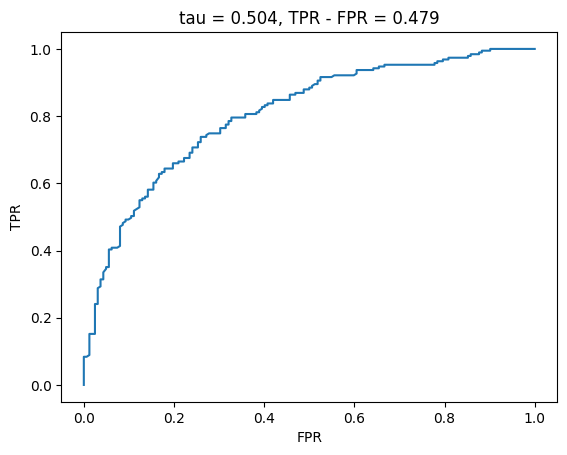

In [ ]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(model(X_test), y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

In [ ]:
accuracy = pd.DataFrame(columns = ["tau", "acc", "tpr", "fpr", "prec", "roc"])

In [ ]:
from sklearn.metrics import roc_auc_score

print(best)
acc, tpr, fpr, prec = error_measures(model(X_test), y_test, best[0], roc = 0)
with torch.no_grad():
    roc = (roc_auc_score(y_test, model(X_test)))
    print(roc)
accuracy.loc[len(accuracy)] = [best[0], acc, tpr, fpr, prec, roc]

(0.504, 0.4789606360286988)

        Accuracy: 0.7393767705382436
        TPR: 0.7382198952879581
        FPR: 0.25925925925925924
        Precision: 0.7704918032786885
        
0.8056363518841705


In [ ]:
accuracy.to_csv("accuracy.csv", index = False)
accuracy

,tau,acc,tpr,fpr,prec,roc
0,0.469,0.753541,0.801047,0.302469,0.757426,0.815170
1,0.422,0.762040,0.816754,0.302469,0.760976,0.808545
2,0.501,0.756374,0.753927,0.240741,0.786885,0.809224
3,0.527,0.753541,0.759162,0.253086,0.779570,0.812326
4,0.461,0.756374,0.780105,0.271605,0.772021,0.815041
5,0.480,0.756374,0.769634,0.259259,0.777778,0.810193
6,0.483,0.753541,0.769634,0.265432,0.773684,0.810581
7,0.504,0.739377,0.738220,0.259259,0.770492,0.805636


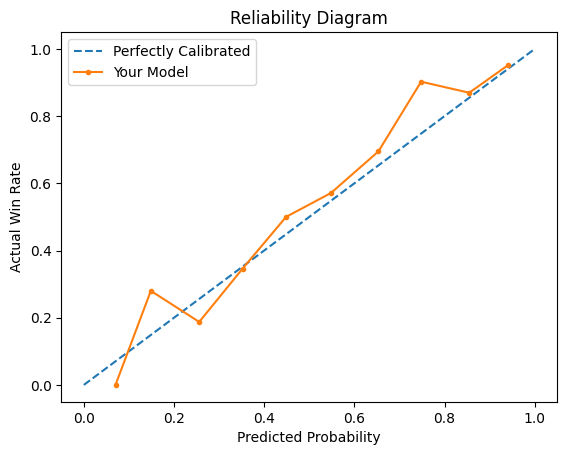

In [ ]:
from sklearn.calibration import calibration_curve

# 1. Get raw probabilities (don't use the threshold yet!)
model.eval()
with torch.no_grad():
    probs = model(X_test).cpu().numpy()

# 2. Calculate calibration
# n_bins=10 means we check buckets: 0-10%, 10-20%, etc.
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

# 3. Plot
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred, prob_true, marker='.', label='Your Model')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.legend()
plt.title('Reliability Diagram')
plt.show()

In [ ]:
torch.save(best_model_state, "mod23.pth")

# trees

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
from time import time
from google.colab import files

## looping

In [ ]:
nested_CV = {
    "rf" : {"model" : RandomForestClassifier(random_state = 0),
                      "params" : {
    "n_estimators": range(25,225,25),
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : [None] + list(range(1,10)),
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : range(1,11),
    "max_features" : ["sqrt","log2",.2,.5]
}},
    "ada" : {"model" : AdaBoostClassifier(random_state = 0),
             "params" : {
    "n_estimators" : range(10,160,10),
    "learning_rate" : list(i/10 for i in range(1,11))
}},
    "xgb" : {"model" : XGBClassifier(),
             "params" : {
    "booster" : ["gbtree", "dart"],
    "eta" : [.0001,.001,.005, .01, .025, .05, .1, .25, .5, 1],
    "gamma" : [0, .5, 1, 2, 5, 10],
    "max_depth" : [1, 2, 4, 6, 12, 15],
    "min_child_weight" : [1, 2, 4, 5]
}},
    "svc" : {"model" : SVC(random_state=0, probability=True),
             "params" : {
    "C" : list(i/10 for i in range(1,51)),
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : range(1,16),
    "gamma" : ["scale", "auto", 0.005, 0.5]
}},
    "bag" : {"model" : BaggingClassifier(random_state=0),
             "params" : {
    "n_estimators" : range(1,251),
    "max_samples" : [ 0.2, 0.5, 0.75, 1],
    "max_features" : [0.2, 0.4, 0.5, 0.7, 1]
}},
    "gb" : {"model" : GradientBoostingClassifier(random_state=0),
            "params" : {
    "loss" : ["log_loss", "exponential"],
    "learning_rate" : [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1, 0.2, .5, 0.6, 1],
    "n_estimators" : range(10,260,10),
    "criterion" : ["friedman_mse", "squared_error"],
    "min_samples_split" : [2, 4, 5, 8, 10],
    "max_depth" : [2, 3, 4, 5, 8, 10],
    "max_features": ["sqrt","log2", 0.1, 0.2, 0.4, 0.5, 0.8, 1]
}},
    "sgd" : {"model" : SGDClassifier(random_state=0),
             "params" : {
    "loss" : ["log_loss"],
    "penalty" : ["elasticnet"],
    "l1_ratio" : [0, 0.001, 0.005, .01, .05, .1, .25, .5, .7, .9, .95, 1],
    "learning_rate" : ["optimal", "adaptive"],
    "eta0" : [0.0001, .0005, .001, .005, .01, .025, .05, .1],
    "early_stopping" : [True, False]
}}
}

In [ ]:
start = time()
for model in ['nn', 'rf', 'ada', 'xgb', 'svc', 'bag', 'gb', 'log', 'sgd']:
    if model not in {"nn", "log"}:
        # pipe = Pipeline([("pca_scaler", pca), (model, nested_CV[model]["model"])])
        # curr_model = RandomizedSearchCV(pipe, nested_CV[model]["params"],
        #                                 n_jobs = -1, n_iter = 150)
        curr_model = RandomizedSearchCV(nested_CV[model]["model"],
                                        nested_CV[model]["params"],
                                         n_jobs = -1, n_iter = 150,
                                        scoring = "neg_log_loss")
        curr_model.fit(X_train_scaled, y_train.ravel())
        print(f"Model {model} done")
        print(f"Time elpased: {round((time() - start)/60,2)} minutes")
        print(curr_model.best_params_)
        print()
        with open(f'{model}_23.pkl', 'wb') as f:
            pickle.dump(curr_model.best_estimator_, f)
        files.download(f"{model}_23.pkl")

Model rf done
Time elpased: 6.95 minutes
{'n_estimators': 175, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 5, 'criterion': 'log_loss'}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model ada done
Time elpased: 12.51 minutes
{'n_estimators': 20, 'learning_rate': 0.2}



<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model sgd done
Time elpased: 41.71 minutes
{'penalty': 'elasticnet', 'loss': 'log_loss', 'learning_rate': 'adaptive', 'l1_ratio': 0.95, 'eta0': 0.1, 'early_stopping': True}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.pipeline import Pipeline

log = Pipeline([("scaler", scaler), ("log", LogisticRegressionCV())])
log.set_params(log__Cs = 30, log__l1_ratios = [.01, .05, .1, .3, .5, .7, .9],
               log__cv = 10, log__scoring = "neg_log_loss", log__max_iter = 1000,
               log__penalty = "elasticnet", log__solver = "saga")
log.fit(X_train, y_train.ravel())

Pipeline(steps=[('scaler', StandardScaler()),
                ('log',
                 LogisticRegressionCV(Cs=30, cv=10,
                                      l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7,
                                                 0.9],
                                      max_iter=1000, penalty='elasticnet',
                                      scoring='neg_log_loss', solver='saga'))])

In [ ]:
log.named_steps['log']
log.named_steps['log'].C_, log.named_steps['log'].l1_ratio_

(array([1.3738238]), array([0.01]))

In [ ]:
import pickle

with open('log_23.pkl', 'wb') as f:
    pickle.dump(log, f)

# manual

## random forest

In [ ]:
params = {
    "n_estimators": range(25,225,25),
    # "n_estimators": range(25,325,25),
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : [None] + list(range(1,10)),
    "min_samples_split" : [2,5,10],
    #  "min_samples_split" : range(2,11,2),
    "min_samples_leaf" : range(1,11),
    "max_features" : ["sqrt","log2",.2,.5]
    # "max_features" : ["sqrt","log2"] + list(range(1,16))
}
# rf = GridSearchCV(RandomForestClassifier(random_state=0), params)
rf = RandomizedSearchCV(RandomForestClassifier(random_state=0), params,
                        n_iter=150, n_jobs = -1, scoring = "neg_log_loss")
rf.fit(X_train, y_train.reshape(-1,))

KeyboardInterrupt: 

In [ ]:
rf.best_params_

{'n_estimators': 125,
 'min_samples_split': 2,
 'min_samples_leaf': 8,
 'max_features': 'sqrt',
 'max_depth': 9,
 'criterion': 'entropy'}

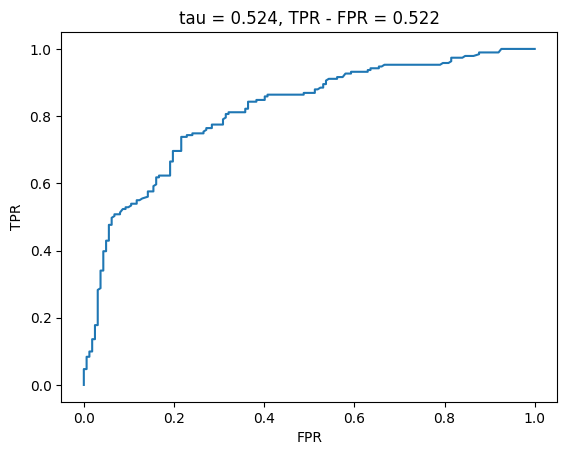

(0.524, 0.5221705125719087)

        Accuracy: 0.7592067988668555
        TPR: 0.7382198952879581
        FPR: 0.21604938271604937
        Precision: 0.8011363636363636
        
None
0.8142330812487881


In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(rf.predict_proba(X_test)[:,1], y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(rf.predict_proba(X_test)[:,1], y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

In [ ]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

## ada

In [ ]:
params = {
    "n_estimators" : range(10,160,10),
    "learning_rate" : list(i/10 for i in range(1,11))
}
ada = RandomizedSearchCV(AdaBoostClassifier(random_state=0), params,
                         n_iter = 150, n_jobs = -1)
ada.fit(X_train, y_train.reshape(-1,))

RandomizedSearchCV(estimator=AdaBoostClassifier(random_state=0), n_iter=150,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.3, 0.4,
                                                          0.5, 0.6, 0.7, 0.8,
                                                          0.9, 1.0],
                                        'n_estimators': range(10, 160, 10)})

In [ ]:
ada.best_params_

{'n_estimators': 130, 'learning_rate': 0.2}

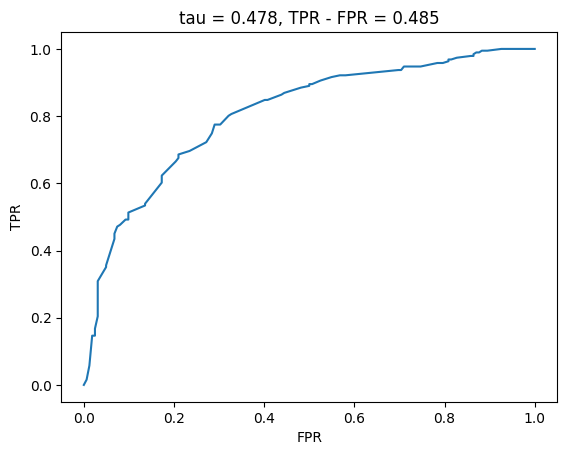

(0.478, 0.48474565315752055)

        Accuracy: 0.7450424929178471
        TPR: 0.774869109947644
        FPR: 0.29012345679012347
        Precision: 0.7589743589743589
        
0.8065089522332106


In [ ]:
y_pred = ada.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
with open('ada_boost_model.pkl', 'wb') as f:
    pickle.dump(ada, f)

## bagging

In [ ]:
params = {
    "n_estimators" : range(1,251),
    "max_samples" : [ 0.2, 0.5, 0.75, 1],
    "max_features" : [0.2, 0.4, 0.5, 0.7, 1]
}
bag = RandomizedSearchCV(BaggingClassifier(random_state = 0),
                         params, n_iter = 150, n_jobs = -1)
bag.fit(X_train, y_train.reshape(-1,))

RandomizedSearchCV(estimator=BaggingClassifier(random_state=0), n_iter=150,
                   n_jobs=-1,
                   param_distributions={'max_features': [0.2, 0.4, 0.5, 0.7, 1],
                                        'max_samples': [0.2, 0.5, 0.75, 1],
                                        'n_estimators': range(1, 251)})

In [ ]:
bag.best_params_

{'n_estimators': 136, 'max_samples': 0.75, 'max_features': 0.5}

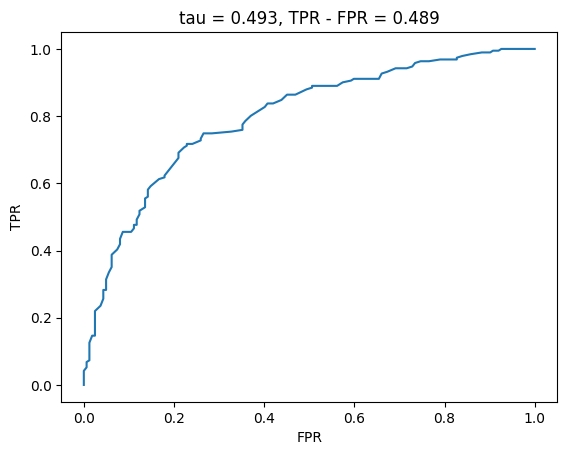

(0.493, 0.4888824251825997)

        Accuracy: 0.7422096317280453
        TPR: 0.7172774869109948
        FPR: 0.22839506172839505
        Precision: 0.7873563218390804
        
0.7968295520651542


In [ ]:
y_pred = bag.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
with open('bagging_classifier_model.pkl', 'wb') as f:
    pickle.dump(bag, f)

## gradient boosted

In [ ]:
params = {
    "loss" : ["log_loss", "exponential"],
    "learning_rate" : [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1, 0.2, .5, 0.6, 1],
    "n_estimators" : range(10,260,10),
    "criterion" : ["friedman_mse", "squared_error"],
    "min_samples_split" : [2, 4, 5, 8, 10],
    "max_depth" : [2, 3, 4, 5, 8, 10],
    "max_features": ["sqrt","log2", 0.1, 0.2, 0.4, 0.5, 0.8, 1]
}
GB = RandomizedSearchCV(GradientBoostingClassifier(random_state = 0),
                         params, n_iter = 200, n_jobs = -1)
GB.fit(X_train, y_train.reshape(-1,))

RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=0),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.001, 0.005, 0.01,
                                                          0.025, 0.05, 0.075,
                                                          0.1, 0.2, 0.5, 0.6,
                                                          1],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': [2, 3, 4, 5, 8, 10],
                                        'max_features': ['sqrt', 'log2', 0.1,
                                                         0.2, 0.4, 0.5, 0.8,
                                                         1],
                                        'min_samples_split': [2, 4, 5, 8, 10],
                                        'n_estimators': range(10, 260, 10)})

In [ ]:
GB.best_params_

{'n_estimators': 70,
 'min_samples_split': 4,
 'max_features': 0.1,
 'max_depth': 5,
 'loss': 'exponential',
 'learning_rate': 0.05,
 'criterion': 'friedman_mse'}

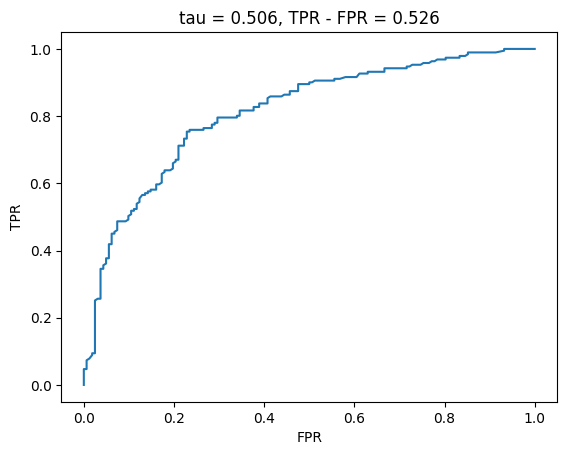

(0.506, 0.5255316398422856)

        Accuracy: 0.7620396600566572
        TPR: 0.7539267015706806
        FPR: 0.22839506172839505
        Precision: 0.7955801104972375
        
0.8112920948872083


In [ ]:
y_pred = GB.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
with open('gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(GB, f)

## XGB

In [ ]:
params = {
    "booster" : ["gbtree", "dart"],
    "eta" : [.0001,.001,.005, .01, .025, .05, .1, .25, .5, 1],
    "gamma" : [0, .5, 1, 2, 5, 10],
    "max_depth" : [1, 2, 4, 6, 12, 15],
    "min_child_weight" : [1, 2, 4, 5]
}
XGB = RandomizedSearchCV(XGBClassifier(), params,
                         n_iter = 150, n_jobs = -1)
XGB.fit(X_train, y_train.reshape(-1,))

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'booster': ['gbtree', 'dart'],
                                        'eta': [0.0001, 0.001, 0.005, 0.01,
                                                0.025, 0.05, 0.1, 0.25, 0.5,
                                                1],
                                        'gamma': [0, 0.5, 1, 2, 5, 10],
                                        'max_depth': [1, 2, 4, 6, 12, 15],
                                        'min_child_weight': [1, 2, 4, 5]})

In [ ]:
XGB.best_params_

{'min_child_weight': 1,
 'max_depth': 15,
 'gamma': 2,
 'eta': 0.025,
 'booster': 'gbtree'}

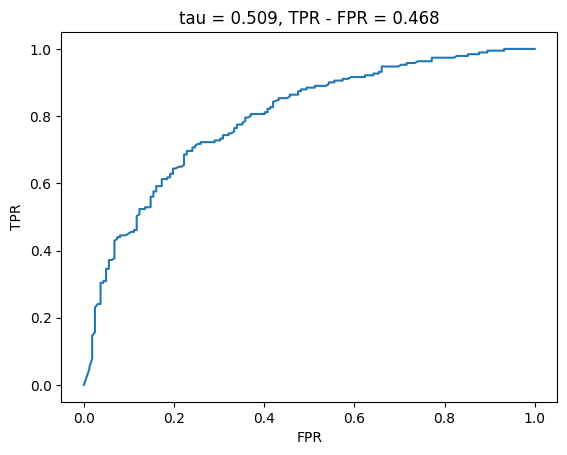

(0.509, 0.46794001680563635)

        Accuracy: 0.7308781869688386
        TPR: 0.6963350785340314
        FPR: 0.22839506172839505
        Precision: 0.7823529411764706
        
0.7950843513670739


In [ ]:
y_pred = XGB.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
with open('XGB_model.pkl', 'wb') as f:
    pickle.dump(XGB, f)

# SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
params = {
    "C" : list(i/10 for i in range(1,51)),
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : range(1,16),
    "gamma" : ["scale", "auto", 0.005, 0.5]
}
svc = RandomizedSearchCV(SVC(random_state=0, probability=True),
                         params,
                         n_iter = 150, n_jobs = -1)
svc.fit(X_train, y_train.reshape(-1,))

RandomizedSearchCV(estimator=SVC(probability=True, random_state=0), n_iter=150,
                   n_jobs=-1,
                   param_distributions={'C': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
                                              0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4,
                                              1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1,
                                              2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
                                              2.9, 3.0, ...],
                                        'degree': range(1, 16),
                                        'gamma': ['scale', 'auto', 0.005, 0.5],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']})

In [ ]:
svc.best_params_

{'kernel': 'poly', 'gamma': 'scale', 'degree': 1, 'C': 2.0}

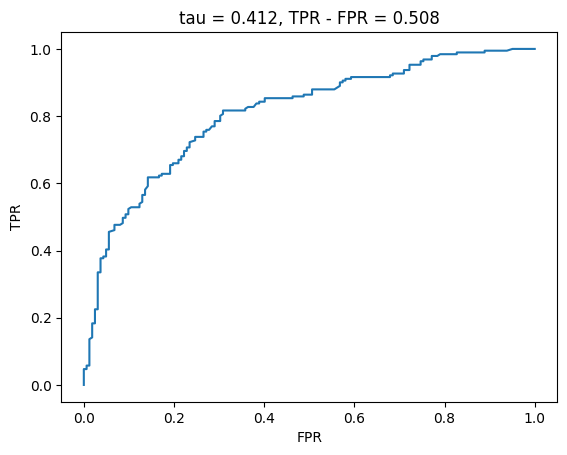

(0.412, 0.5081119513929286)

        Accuracy: 0.7592067988668555
        TPR: 0.8167539267015707
        FPR: 0.30864197530864196
        Precision: 0.7572815533980582
        
0.8097408053778038


In [ ]:
y_pred = svc.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
with open('SVC_model.pkl', 'wb') as f:
    pickle.dump(svc, f)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
X_data = pd.concat([db_used, mirrored]).copy()
# X_data = X_data.loc[:,list(c for c in X_data.columns if "team" not in c)]
# vif_data = pd.DataFrame()
# vif_data["feature"] = X_data.columns
# vif_data["VIF"] = [variance_inflation_factor(X_data.values, i)
#                           for i in range(len(X_data.columns))]
# vif_data

In [ ]:
pd.concat([X_data.reset_index().drop("index", axis = 1),
           pd.DataFrame({"win" : y.reshape(-1,)})], axis = 1).to_csv("X_df.csv", index = False)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegressionCV, LassoLarsCV, ElasticNetCV, SGDClassifier
from sklearn.pipeline import Pipeline

In [ ]:
log = Pipeline([("scaler", scaler), ("log", LogisticRegressionCV())])
log.set_params(log__Cs = 30, log__l1_ratios = [.01, .05, .1, .3, .5, .7, .9],
               log__cv = 10, log__scoring = "neg_log_loss", log__max_iter = 1000,
               log__penalty = "elasticnet", log__solver = "saga")
log.fit(X_train, y_train.ravel())

Pipeline(steps=[('scaler', StandardScaler()),
                ('log',
                 LogisticRegressionCV(Cs=30, cv=10,
                                      l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7,
                                                 0.9],
                                      max_iter=1000, penalty='elasticnet',
                                      scoring='neg_log_loss', solver='saga'))])

In [ ]:
log.named_steps["log"].l1_ratio_

array([0.01])

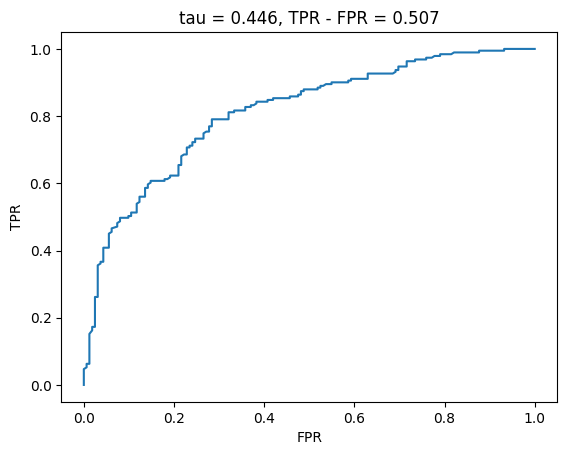

(0.446, 0.506625298946416)

        Accuracy: 0.7563739376770539
        TPR: 0.7905759162303665
        FPR: 0.2839506172839506
        Precision: 0.766497461928934
        
0.8106780427897357


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = log.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
import pickle

with open('Logistic_Regression_model.pkl', 'wb') as f:
    pickle.dump(log, f)

## SGD

In [ ]:
# ridge doesnt have predict proba

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([("scaler", scaler), ("SGD", SGDClassifier())])

params = {
    "SGD__loss" : ["log_loss"],
    "SGD__penalty" : ["elasticnet"],
    "SGD__l1_ratio" : [0, 0.001, 0.005, .01, .05, .1, .25, .5, .7, .9, .95, 1],
    "SGD__learning_rate" : ["optimal", "adaptive"],
    "SGD__eta0" : [0.0001, .0005, .001, .005, .01, .025, .05, .1],
    "SGD__early_stopping" : [True, False]
}

sgd = RandomizedSearchCV(pipe, params, n_jobs = -1, n_iter = 150)

sgd.fit(X_train, y_train.ravel())

RandomizedSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('SGD', SGDClassifier())]),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'SGD__early_stopping': [True, False],
                                        'SGD__eta0': [0.0001, 0.0005, 0.001,
                                                      0.005, 0.01, 0.025, 0.05,
                                                      0.1],
                                        'SGD__l1_ratio': [0, 0.001, 0.005, 0.01,
                                                          0.05, 0.1, 0.25, 0.5,
                                                          0.7, 0.9, 0.95, 1],
                                        'SGD__learning_rate': ['optimal',
                                                               'adaptive'],
                                        'SGD__loss': ['log_loss'],
                                        'SGD__penalty': ['elasticnet']})

In [ ]:
sgd.best_params_

{'SGD__penalty': 'elasticnet',
 'SGD__loss': 'log_loss',
 'SGD__learning_rate': 'adaptive',
 'SGD__l1_ratio': 0.05,
 'SGD__eta0': 0.005,
 'SGD__early_stopping': True}

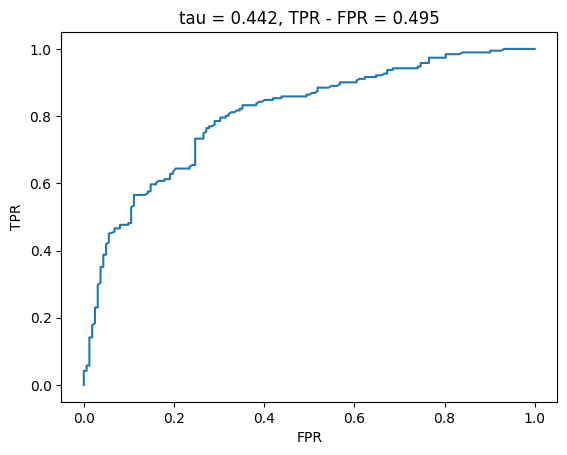

(0.442, 0.49521685734600224)

        Accuracy: 0.7507082152974505
        TPR: 0.7853403141361257
        FPR: 0.29012345679012347
        Precision: 0.7614213197969543
        
0.8056686704156164


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = sgd.predict_proba(X_test)[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

In [ ]:
import pickle

with open('SGD_model.pkl', 'wb') as f:
    pickle.dump(sgd, f)

# Voting

## old models

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

In [ ]:
NN = Model(23, n_layers = 3, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod23.pth"))

NN.eval()

nn_probs = NN(X_test).reshape(-1).detach().numpy()

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

with open('random_forest_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('ada_boost_model.pkl', 'rb') as f:
    ada = pickle.load(f)

with open('XGB_model.pkl', 'rb') as f:
    XGB = pickle.load(f)

with open('standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open("SGD_model.pkl", "rb") as f:
    SGD = pickle.load(f)

with open("SVC_model.pkl", "rb") as f:
    svc = pickle.load(f)

with open("bagging_classifier_model.pkl", "rb") as f:
    bag = pickle.load(f)

with open("gradient_boosting_model.pkl", "rb") as f:
    gb = pickle.load(f)

with open("Logistic_Regression_model.pkl", "rb") as f:
    log = pickle.load(f)

rf_probs = rf.predict_proba(X_test)[:,-1]
ada_probs = ada.predict_proba(X_test)[:,-1]
xgb_probs = XGB.predict_proba(X_test)[:,-1]
svc_probs = svc.predict_proba(X_test)[:,1]
bag_probs = bag.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]
log_probs = log.predict_proba(X_test)[:,1]
sgd_probs = sgd.predict_proba(X_test)[:,1]

## new models

In [ ]:
models = ["nn", "rf", "ada", "xgb", "svc", "bag", "gb", "log", "sgd"]
for model in models:
    print(f"""
    with open("{model}_23.pkl", "rb") as f:
        {model} = pickle.load(f)""")


    with open("nn_23.pkl", "rb") as f:
        nn = pickle.load(f)

    with open("rf_23.pkl", "rb") as f:
        rf = pickle.load(f)

    with open("ada_23.pkl", "rb") as f:
        ada = pickle.load(f)

    with open("xgb_23.pkl", "rb") as f:
        xgb = pickle.load(f)

    with open("svc_23.pkl", "rb") as f:
        svc = pickle.load(f)

    with open("bag_23.pkl", "rb") as f:
        bag = pickle.load(f)

    with open("gb_23.pkl", "rb") as f:
        gb = pickle.load(f)

    with open("log_23.pkl", "rb") as f:
        log = pickle.load(f)

    with open("sgd_23.pkl", "rb") as f:
        sgd = pickle.load(f)


In [ ]:
from skorch import NeuralNetClassifier

with open("nn_23.pkl", "rb") as f:
    nn = pickle.load(f)

nn_probs = nn.predict_proba(X_test_scaled)[:,-1,0]

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

# with open("nn_23.pkl", "rb") as f:
#     nn = pickle.load(f)

with open("rf_23.pkl", "rb") as f:
    rf = pickle.load(f)

with open("ada_23.pkl", "rb") as f:
    ada = pickle.load(f)

with open("xgb_23.pkl", "rb") as f:
    xgb = pickle.load(f)

with open("svc_23.pkl", "rb") as f:
    svc = pickle.load(f)

with open("bag_23.pkl", "rb") as f:
    bag = pickle.load(f)

with open("gb_23.pkl", "rb") as f:
    gb = pickle.load(f)

with open("log_23.pkl", "rb") as f:
    log = pickle.load(f)

with open("sgd_23.pkl", "rb") as f:
    sgd = pickle.load(f)

rf_probs = rf.predict_proba(X_test_scaled)[:,-1]
ada_probs = ada.predict_proba(X_test_scaled)[:,-1]
xgb_probs = xgb.predict_proba(X_test_scaled)[:,-1]
svc_probs = svc.predict_proba(X_test_scaled)[:,1]
bag_probs = bag.predict_proba(X_test_scaled)[:,1]
gb_probs = gb.predict_proba(X_test_scaled)[:,1]
log_probs = log.predict_proba(X_test)[:,1]
sgd_probs = sgd.predict_proba(X_test_scaled)[:,1]

In [ ]:
models = ["nn", "rf", "ada", "xgb", "svc", "bag", "gb", "log", "sgd"]
s: str = ""
for i in range(len(models)):
    s += f"c{i + 1} * {models[i]}_probs + "
s

'c1 * nn_probs + c2 * rf_probs + c3 * ada_probs + c4 * xgb_probs + c5 * svc_probs + c6 * bag_probs + c7 * gb_probs + c8 * log_probs + c9 * sgd_probs + '

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# Generate 500 random weight combinations that sum to 1
num_trials = 5000
weight_samples = np.random.dirichlet(np.ones(9), size=num_trials)

results = []

for weights in weight_samples:
    c1, c2, c3, c4, c5, c6, c7, c8, c9 = weights

    # Calculate ensemble prediction
    vote_pred = (c1 * nn_probs + c2 * rf_probs + c3 * ada_probs + c4 * xgb_probs +
                 c5 * svc_probs + c6 * bag_probs + c7 * gb_probs + c8 * log_probs +
                 c9 * sgd_probs)

    # Use sklearn to find best threshold (much faster than 0-1001 loop)
    fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
    j_scores = tpr_list - fpr_list
    best_tau = thresholds[np.argmax(j_scores)]

    # Calculate metrics at best_tau
    y_bin = (vote_pred >= best_tau).astype(int)
    acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
    loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
     (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

    results.append({
        'weights': weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list),
        "loss" : loss
    })

# Find the winner
best_run = min(results, key=lambda x: x['loss'])
print(f"Best Weights: {best_run['weights']}")
print(f"Max Accuracy: {best_run['acc']}")

Best Weights: [0.00507499 0.07496911 0.10588053 0.00531576 0.05534065 0.0580679
 0.00198276 0.60371626 0.08965204]
Max Accuracy: 0.7396226415094339


In [ ]:
# WHAT THE HELL??
best_run

{'weights': array([0.01296476, 0.10529147, 0.03491868, 0.01611117, 0.02467161,
        0.16622749, 0.0229785 , 0.02166676, 0.59516957]),
 'tau': np.float64(0.5493636672888126),
 'acc': np.float64(0.7433962264150943),
 'auc': np.float64(0.8183142857142858),
 'loss': np.float64(0.5227661309012849)}

In [ ]:
best_run

{'weights': array([0.00507499, 0.07496911, 0.10588053, 0.00531576, 0.05534065,
        0.0580679 , 0.00198276, 0.60371626, 0.08965204]),
 'tau': np.float64(0.5756717371142184),
 'acc': np.float64(0.7396226415094339),
 'auc': np.float64(0.8187714285714287),
 'loss': np.float64(0.5218425226286043)}

In [ ]:
best_run

{'weights': array([0.02908015, 0.00785943, 0.04610885, 0.0586545 , 0.06876843,
        0.10651248, 0.01033003, 0.59820656, 0.07447957]),
 'tau': np.float64(0.46506910115005895),
 'acc': np.float64(0.7490566037735849),
 'auc': np.float64(0.8183142857142857),
 'loss': np.float64(0.5220637363258297)}

In [ ]:
models = ["nn", "rf", "ada", "xgb", "svc", "bag", "gb", "log", "sgd"]
s: str = ""
for i in range(len(models)):
    s += f"w[{i}] * {models[i]}_probs + "
    if i == len(models) - 1:
        s = s[:-3]
s

'w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs + w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs + w[8] * sgd_probs'

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs) # +
        # w[4] * svc_probs + w[5] * bag_probs) # + w[6] * gb_probs + w[7] * log_probs +
        #  w[8] * sgd_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_test.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]

n = 4
initial_guess = np.ones(n)/n
bounds = [(0, 1)] * n # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [0.18043241 0.67783561 0.14173198 0.        ]


In [ ]:
np.round(best_weights, 3)

array([0.18 , 0.678, 0.142, 0.   ])

In [ ]:
objective(best_weights)

0.5211513262704796

In [ ]:
results = []
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# vote_pred = .2127*bag_probs + .4884*sgd_probs + .2987*log_probs
vote_pred = nn_probs

fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
  (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

results.append({
    # 'weights': weights,
    'tau': best_tau,
    'acc': acc,
    "tpr" : tpr_list[np.argmax(j_scores)],
    "fpr" : fpr_list[np.argmax(j_scores)],
    'auc': auc(fpr_list, tpr_list),
    "loss" : loss
})

# Find the winner
# best_run = min(results, key=lambda x: x['loss'])
# print(f"Best Weights: {best_run['weights']}")
# print(f"Max Accuracy: {best_run['acc']}")
results

[{'tau': np.float32(0.5295506),
  'acc': np.float64(0.7433962264150943),
  'tpr': np.float64(0.7178571428571429),
  'fpr': np.float64(0.228),
  'auc': np.float64(0.8003428571428572),
  'loss': np.float32(0.54485947)}]

In [ ]:
objective([0.34, 0.33,0, 0.33] + [0]*5)

0.535611834170445

OLD MODELS (IMPORPERLY TRAINED)

NN weight = 0.4402
GB weight = 0.3995
Log weight = 0.1603

NEW WEIGHTS WITH NEW MODELS
NO LEAKAGE\
``vote_pred = .134*svc_probs + .223*bag_probs + .642*sgd_probs``
^ using scaled data on logistic regression pipeline, double scaling

``vote_pred = .2127*bag_probs + .4884*sgd_probs + .2987*log_probs``

In [ ]:
# nn best only

#   'tau': np.float32(0.5295506),
#   'acc': np.float64(0.7433962264150943),
#   'auc': np.float64(0.8003428571428572),
#   'loss': np.float32(0.54485947)}]

### valid set voting

In [ ]:
nn_probs = nn.predict_proba(X_valid_scaled)[:,-1,0]
rf_probs = rf.predict_proba(X_valid_scaled)[:,-1]
ada_probs = ada.predict_proba(X_valid_scaled)[:,-1]
xgb_probs = xgb.predict_proba(X_valid_scaled)[:,-1]
svc_probs = svc.predict_proba(X_valid_scaled)[:,1]
bag_probs = bag.predict_proba(X_valid_scaled)[:,1]
gb_probs = gb.predict_proba(X_valid_scaled)[:,1]
log_probs = log.predict_proba(X_valid_scaled)[:,1]
sgd_probs = sgd.predict_proba(X_valid_scaled)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# Generate 500 random weight combinations that sum to 1
num_trials = 5000
weight_samples = np.random.dirichlet(np.ones(9), size=num_trials)

results = []

for weights in weight_samples:
    c1, c2, c3, c4, c5, c6, c7, c8, c9 = weights

    # Calculate ensemble prediction
    vote_pred = (c1 * nn_probs + c2 * rf_probs + c3 * ada_probs + c4 * xgb_probs +
                 c5 * svc_probs + c6 * bag_probs + c7 * gb_probs + c8 * log_probs +
                 c9 * sgd_probs)

    # Use sklearn to find best threshold (much faster than 0-1001 loop)
    fpr_list, tpr_list, thresholds = roc_curve(y_valid, vote_pred)
    j_scores = tpr_list - fpr_list
    best_tau = thresholds[np.argmax(j_scores)]

    # Calculate metrics at best_tau
    y_bin = (vote_pred >= best_tau).astype(int)
    acc = (y_bin == y_valid.reshape(-1).detach().numpy()).mean()
    loss = -np.mean(y_valid.numpy().ravel()*np.log(vote_pred) +
     (1 - y_valid.numpy().ravel())*np.log(1 - vote_pred) )

    results.append({
        'weights': weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list),
        "loss" : loss
    })

# Find the winner
best_run = min(results, key=lambda x: x['loss'])
print(f"Best Weights: {best_run['weights']}")
print(f"Max Accuracy: {best_run['acc']}")

Best Weights: [0.01099303 0.01652994 0.0398146  0.04065256 0.03874641 0.66289254
 0.11492528 0.01212787 0.06331777]
Max Accuracy: 0.8106575963718821


In [ ]:
best_run

{'weights': array([0.04133725, 0.04189579, 0.09981202, 0.07373927, 0.07276355,
        0.60025017, 0.03474326, 0.01983692, 0.01562177]),
 'tau': np.float64(0.521047362089205),
 'acc': np.float64(0.8027210884353742),
 'auc': np.float64(0.8782751091703056),
 'loss': np.float64(0.45995685100884254)}

In [ ]:
best_run

{'weights': array([0.01099303, 0.01652994, 0.0398146 , 0.04065256, 0.03874641,
        0.66289254, 0.11492528, 0.01212787, 0.06331777]),
 'tau': np.float64(0.5007129769160104),
 'acc': np.float64(0.8106575963718821),
 'auc': np.float64(0.8818025459339212),
 'loss': np.float64(0.4543715039938769)}

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
         w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
         w[8] * sgd_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_valid.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]
initial_guess = np.ones(9)/9
bounds = [(0, 1)] * 9 # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:
objective(best_weights)

0.4323372662140486

In [ ]:
results = []

vote_pred = bag_probs + 1e-16

fpr_list, tpr_list, thresholds = roc_curve(y_valid, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_valid.reshape(-1).detach().numpy()).mean()
loss = -np.mean(y_valid.numpy().ravel()*np.log(vote_pred) +
  (1 - y_valid.numpy().ravel())*np.log(1 - vote_pred) )

results.append({
    'weights': weights,
    'tau': best_tau,
    'acc': acc,
    'auc': auc(fpr_list, tpr_list),
    "loss" : loss
})

# Find the winner
# best_run = min(results, key=lambda x: x['loss'])
# print(f"Best Weights: {best_run['weights']}")
# print(f"Max Accuracy: {best_run['acc']}")
results

[{'weights': array([0.10697139, 0.24797698, 0.16529971, 0.03826046, 0.09999079,
         0.27645084, 0.01801679, 0.00286124, 0.04417179]),
  'tau': np.float64(0.5110132158590309),
  'acc': np.float64(0.8310657596371882),
  'auc': np.float64(0.8956548158523523),
  'loss': np.float64(0.4323372662140486)}]

# PCA

In [ ]:
# not_included: set[str] = {"season","round","team1","team2","team1_seed","team2_seed","win"}
# X = db.loc[:,list(c for c in db.columns if c not in not_included)]
y = np.array(db["win"]).reshape(-1,1)

X = np.vstack([np.array(db_used), np.array(mirrored)])

# augmenting diffs
y = np.vstack([y, 1 - y])

# y = np.vstack([y.reshape(-1,1), y.reshape(-1,1)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 0)
# X_test, X_valid, y_test, y_valid = train_test_split(X, y, test_size = .5, random_state = 0)


# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# X_valid = scaler.transform(X_valid)

X_train = torch.as_tensor(X_train, dtype = torch.float32)
X_test = torch.as_tensor(X_test, dtype = torch.float32)
# X_valid = torch.as_tensor(X_valid, dtype = torch.float32)
# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)
# y_valid = torch.tensor(y_valid, dtype = torch.float32)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [ ]:
variance = {}
for i in range(X_train.shape[1] + 1):
    pca = Pipeline([ ("scaler", scaler), ("pca", PCA())])
    pca.set_params(pca__random_state=0, pca__n_components=i)
    pca.fit(X_train)
    variance[i] = np.sum(pca.named_steps["pca"].explained_variance_ratio_)

In [ ]:
from plotnine import *

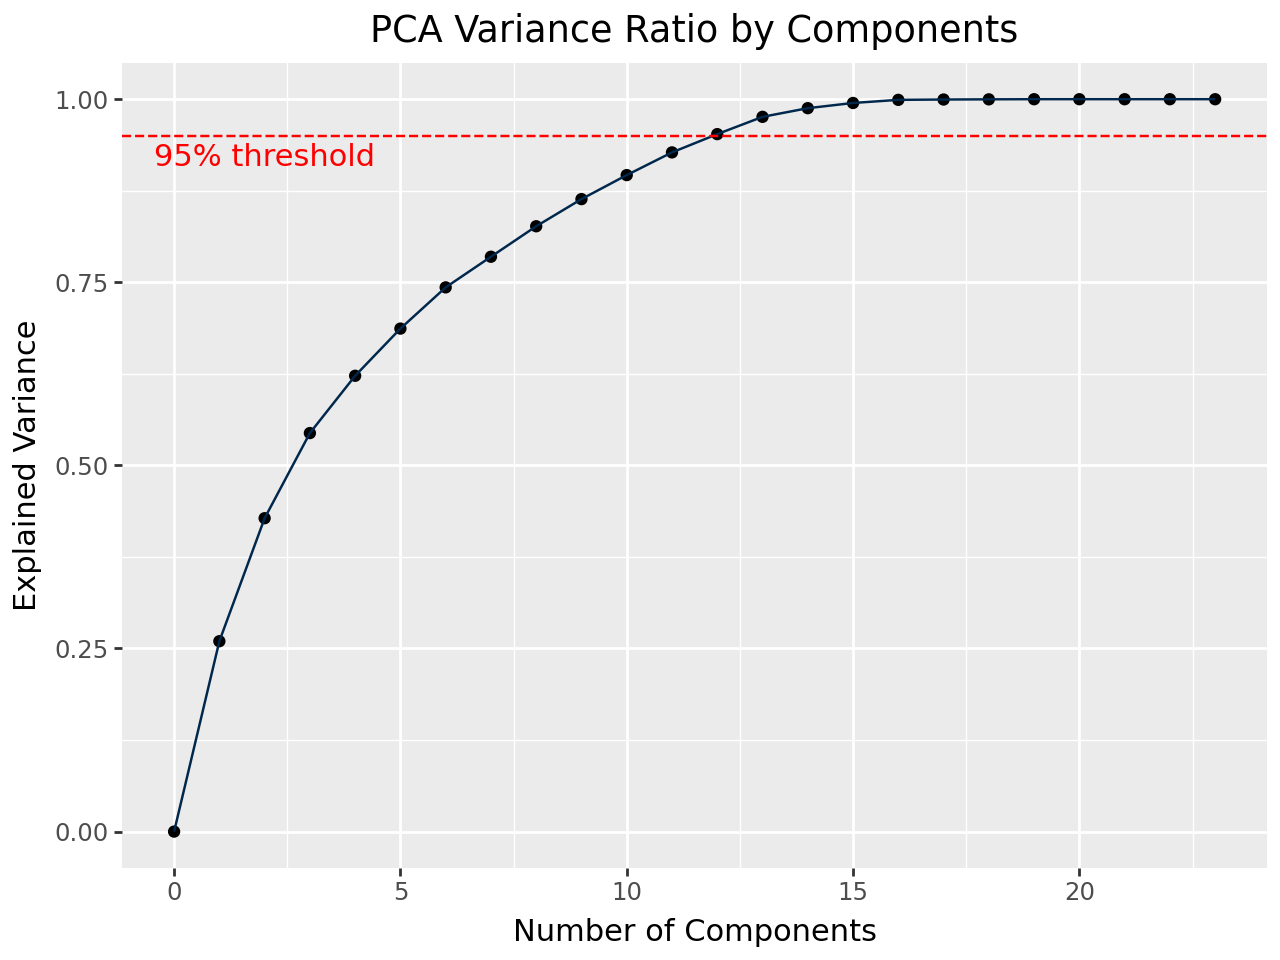

In [ ]:
comps = list(variance.keys())
vars = list(variance.values())
comp = next(i for i in iter(variance) if variance[i] >= .95)
ggplot() + geom_point(aes(x = comps, y = vars)) + geom_line(aes(x = comps, y = vars),
color = "#00274C") + xlab("Number of Components") + ylab("Explained Variance"
) + labs(title = "PCA Variance Ratio by Components") + geom_hline(
    yintercept = .95, linetype = "dashed", color = "red"
) + annotate("text", x = 2, y = .92, label = "95% threshold", color = "red")

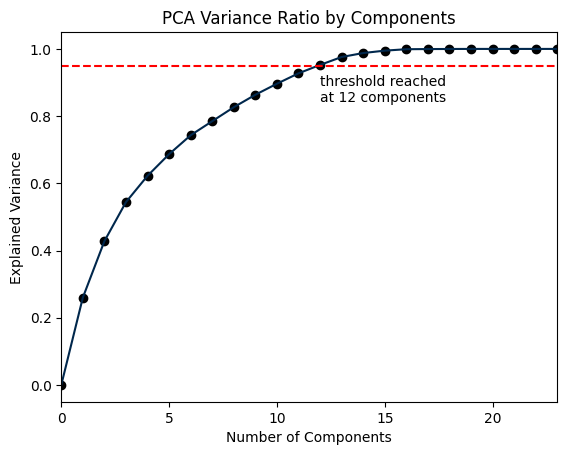

In [ ]:
plt.plot(variance.keys(), variance.values(), color = "#00274C")
plt.scatter(variance.keys(), variance.values(), color = "black")
plt.hlines(y = .95, xmin = 0, xmax = X_train.shape[1], linestyles="dashed", color = "red")
plt.xlim(0, X_train.shape[1])

comp = next(i for i in iter(variance) if variance[i] >= .95)

plt.text(comp, variance[comp] - .11, "threshold reached\nat 12 components")
plt.title("PCA Variance Ratio by Components")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.show()

In [ ]:
with open('scaler_plus_PCA_fitted.pkl', 'wb') as f:
    pickle.dump(pca, f)

In [ ]:
models

['nn', 'rf', 'ada', 'xgb', 'svc', 'bag', 'gb', 'log', 'sgd']

In [ ]:
nested_CV = {
    "rf" : {"model" : RandomForestClassifier(random_state = 0),
                      "params" : {
    "n_estimators": range(25,225,25),
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : [None] + list(range(1,10)),
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : range(1,11),
    "max_features" : ["sqrt","log2",.2,.5]
}},
    "ada" : {"model" : AdaBoostClassifier(random_state = 0),
             "params" : {
    "n_estimators" : range(10,160,10),
    "learning_rate" : list(i/10 for i in range(1,11))
}},
    "xgb" : {"model" : XGBClassifier(),
             "params" : {
    "booster" : ["gbtree", "dart"],
    "eta" : [.0001,.001,.005, .01, .025, .05, .1, .25, .5, 1],
    "gamma" : [0, .5, 1, 2, 5, 10],
    "max_depth" : [1, 2, 4, 6, 12, 15],
    "min_child_weight" : [1, 2, 4, 5]
}},
    "svc" : {"model" : SVC(random_state=0, probability=True),
             "params" : {
    "C" : list(i/10 for i in range(1,51)),
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : range(1,16),
    "gamma" : ["scale", "auto", 0.005, 0.5]
}},
    "bag" : {"model" : BaggingClassifier(random_state=0),
             "params" : {
    "n_estimators" : range(1,251),
    "max_samples" : [ 0.2, 0.5, 0.75, 1],
    "max_features" : [0.2, 0.4, 0.5, 0.7, 1]
}},
    "gb" : {"model" : GradientBoostingClassifier(random_state=0),
            "params" : {
    "loss" : ["log_loss", "exponential"],
    "learning_rate" : [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1, 0.2, .5, 0.6, 1],
    "n_estimators" : range(10,260,10),
    "criterion" : ["friedman_mse", "squared_error"],
    "min_samples_split" : [2, 4, 5, 8, 10],
    "max_depth" : [2, 3, 4, 5, 8, 10],
    "max_features": ["sqrt","log2", 0.1, 0.2, 0.4, 0.5, 0.8, 1]
}},
    "sgd" : {"model" : SGDClassifier(random_state=0),
             "params" : {
    "loss" : ["log_loss"],
    "penalty" : ["elasticnet"],
    "l1_ratio" : [0, 0.001, 0.005, .01, .05, .1, .25, .5, .7, .9, .95, 1],
    "learning_rate" : ["optimal", "adaptive"],
    "eta0" : [0.0001, .0005, .001, .005, .01, .025, .05, .1],
    "early_stopping" : [True, False]
}}
}

In [ ]:
for model in models:
    if model not in {"nn", "log"}:
        print(model)
        temp = list(nested_CV[model]["params"].keys())
        for n in temp:
            nested_CV[model]["params"][f"{model}__{n}"] = nested_CV[model]["params"].pop(n)

rf
ada
xgb
svc
bag
gb
sgd


In [ ]:
from time import time

In [ ]:
from google.colab import files

In [ ]:
start = time()
X_transformed = pca.transform(X_train)
for model in models:
    if model not in {"nn", "log"}:
        # pipe = Pipeline([("pca_scaler", pca), (model, nested_CV[model]["model"])])
        # curr_model = RandomizedSearchCV(pipe, nested_CV[model]["params"],
        #                                 n_jobs = -1, n_iter = 150)
        curr_model = RandomizedSearchCV(nested_CV[model]["model"],
                                        nested_CV[model]["params"],
                                         n_jobs = -1, n_iter = 150,
                                        scoring = "neg_log_loss")
        curr_model.fit(X_transformed, y_train.ravel())
        print(f"Model {model} done")
        print(f"Time elpased: {round((time() - start)/60,2)} minutes")
        # print()
        # with open(f'pca_scaled_{model}.pkl', 'wb') as f:
        #     pickle.dump(curr_model, f)
        # files.download(f"pca_scaled_{model}.pkl")

        print(curr_model.best_params_)
        print()
        with open(f'{model}_pca_scaled_12.pkl', 'wb') as f:
            pickle.dump(curr_model.best_estimator_, f)
        files.download(f"{model}_pca_scaled_12.pkl")

Model rf done
Time elpased: 8.94 minutes
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 6, 'criterion': 'entropy'}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model ada done
Time elpased: 14.02 minutes
{'n_estimators': 40, 'learning_rate': 0.2}



<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model sgd done
Time elpased: 42.97 minutes
{'penalty': 'elasticnet', 'loss': 'log_loss', 'learning_rate': 'adaptive', 'l1_ratio': 0.005, 'eta0': 0.001, 'early_stopping': True}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import pickle

In [ ]:
import pickle

with open("scaler_plus_PCA_fitted.pkl", "rb") as f:
    pca = pickle.load(f)

In [ ]:
# log = Pipeline([("pca_scaler", pca), ("log", LogisticRegressionCV(random_state=0))])
X_transformed = pca.transform(X_train)
log = LogisticRegressionCV(random_state=0)

log.set_params(Cs = 30, l1_ratios = [.01, .05, .1, .3, .5, .7, .9],
               cv = 10, scoring = "neg_log_loss", max_iter = 1000,
               penalty = "elasticnet", solver = "saga")
log.fit(X_transformed, y_train.ravel())

LogisticRegressionCV(Cs=30, cv=10,
                     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9],
                     max_iter=1000, penalty='elasticnet', random_state=0,
                     scoring='neg_log_loss', solver='saga')

In [ ]:
log.C_, log.l1_ratio_
# log.named_steps['log'].C_, log.named_steps['log'].l1_ratio_

(array([0.05736153]), array([0.9]))

In [ ]:
with open("log_pca_scaled_12.pkl", "wb") as f:
    pickle.dump(log, f)

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = log.predict_proba(pca.transform(X_test))[:,1]

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(y_pred, y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"tau = {best[0]}, TPR - FPR = {round(best[1],3)}")
plt.show()

print(best)
(error_measures(y_pred, y_test, best[0], roc = 0))

with torch.no_grad():
    print(roc_auc_score(y_test, y_pred))

ValueError: X has 12 features, but GradientBoostingClassifier is expecting 23 features as input.

In [ ]:
-np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))

np.float64(0.5259271950964979)

## pca nn with cv

In [ ]:
import pickle

with open("scaler_plus_PCA_fitted.pkl", "rb") as f:
    pca = pickle.load(f)

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int , output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        # return self.sigmoid(x)
        return x

In [ ]:
from skorch import NeuralNetClassifier
from sklearn.model_selection import RandomizedSearchCV
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

X_transformed = torch.tensor(pca.transform(X_train), dtype = torch.float32)

net = NeuralNetClassifier(
    module=Model,
    module__input_size=X_transformed.shape[1],
    criterion=torch.nn.BCEWithLogitsLoss,
    optimizer=torch.optim.Adam,
    max_epochs=250,
    verbose=0, # Set to 0 to keep the output clean during search
    callbacks=[EarlyStopping(patience=20, monitor='valid_loss')], # Early Stopping
    train_split=ValidSplit(cv=5) # Required for EarlyStopping to have a validation set
)

params = {
    'lr': [.00005, .0001, .0002, .0005, .001, .002, .004, .005, .01, .025, .05, .1],        # Learning Rate
    'module__n_layers': np.arange(1, 5),                  # Number of Layers
    'module__hidden_dim': [8, 16, 32, 64, 128],          # Hidden Size
    'module__dropout': np.arange(1,1000)/1000,                # Dropout Value
    'optimizer__weight_decay': [0, .0001, .0005, .001, .002, .005, .01, .02, .05, .1, .25], # Lambda (L2 Regularization)
}

rs = RandomizedSearchCV(net, params, n_iter=250, cv=5, scoring='neg_log_loss', n_jobs = -1)
rs.fit(X_transformed, y_train) # X, y as numpy arrays or torch tensors

RandomizedSearchCV(cv=5,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__input_size'}, batch_size=128, callbacks=[<skorch.callbacks.training.EarlyStopping object at 0x7ac652b01f40>], compile=False, criterion=<class 'torch.nn.modules.loss.BCEWithLogitsLoss'>, dataset=<class 'skorch.dataset.Dataset'>, device='cpu', iterator_train=<class 'torch.utils.da...
       0.964, 0.965, 0.966, 0.967, 0.968, 0.969, 0.97 , 0.971, 0.972,
       0.973, 0.974, 0.975, 0.976, 0.977, 0.978, 0.979, 0.98 , 0.981,
       0.982, 0.983, 0.984, 0.985, 0.986, 0.987, 0.988, 0.989, 0.99 ,
       0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999]),
                                        'module__hidden_dim': [8, 16, 32, 64,
                                                               128],
                                        'module__n_layers': array([1, 2, 3, 4]),
                                        'optimizer__weight_decay': [0, 0.0001,
                                                                    0.0005,
                                                                    0.001,
                                                                    0.002,
                                                                    0.005, 0.01,
                                                                    0.02, 0.05,
                                                                    0.1,
                                                                    0.25]},
                   scoring='neg_log_loss')

In [ ]:
# when running 10 iter to test

# {'optimizer__weight_decay': 0.01,
#  'module__n_layers': np.int64(1),
#  'module__hidden_dim': 32,
#  'module__dropout': np.float64(0.706),
#  'lr': 0.002}

# Accuracy: 0.7596371882086168
#         TPR: 0.7830188679245284
#         FPR: 0.26200873362445415
#         Precision: 0.7345132743362832

# test loss np.float32(-0.5115096)


# hmm

# {'optimizer__weight_decay': 0.001,
#  'module__n_layers': np.int64(1),
#  'module__hidden_dim': 64,
#  'module__dropout': np.float64(0.688),
#  'lr': 0.0005}

In [ ]:
rs.best_estimator_

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Model(
    (layers): ModuleList(
      (0): Linear(in_features=12, out_features=128, bias=False)
      (1): Linear(in_features=128, out_features=128, bias=False)
    )
    (bn_layers): ModuleList(
      (0-1): 2 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (dropout): Dropout(p=0.811, inplace=False)
    (output_layer): Linear(in_features=128, out_features=1, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  ),
)

In [ ]:
rs.best_estimator_.optimizer__weight_decay, rs.best_estimator_.lr

(0.0005, 0.002)

In [ ]:
rs.best_params_

{'optimizer__weight_decay': 0.0005,
 'module__n_layers': np.int64(1),
 'module__hidden_dim': 128,
 'module__dropout': np.float64(0.811),
 'lr': 0.002}

In [ ]:
nn = rs.best_estimator_

In [ ]:
from google.colab import files
with open(f'nn_pca_scaled_12.pkl', 'wb') as f:
    pickle.dump(nn, f)
files.download(f"nn_pca_scaled_12.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_pred = nn.predict_proba(torch.tensor(pca.transform(X_test), dtype = torch.float32))[:,-1,0]
error_measures(y_pred, y_test.numpy())
np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))


        Accuracy: 0.7505668934240363
        TPR: 0.7570754716981132
        FPR: 0.2554585152838428
        Precision: 0.7328767123287672
        


np.float32(-0.5055258)

## pca svc fix

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
X_transformed = pca.transform(X_train)

params = {
    "C" : list(i/10 for i in range(1,51)),
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : range(1,16),
    "gamma" : ["scale", "auto", 0.005, 0.5]
}

svc = RandomizedSearchCV(SVC(random_state=0, probability=True), params,
                         n_jobs = -1, n_iter = 150)

svc.fit(X_transformed, y_train.ravel())

RandomizedSearchCV(estimator=SVC(probability=True, random_state=0), n_iter=150,
                   n_jobs=-1,
                   param_distributions={'C': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
                                              0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4,
                                              1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1,
                                              2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
                                              2.9, 3.0, ...],
                                        'degree': range(1, 16),
                                        'gamma': ['scale', 'auto', 0.005, 0.5],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']})

In [ ]:
with open("pca_scaled_svc.pkl", "wb") as f:
    pickle.dump(svc, f)

## PCA NN

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

In [ ]:
X_train_pca = torch.tensor(pca.transform(X_train), dtype = torch.float32)
X_test_pca = torch.tensor(pca.transform(X_test), dtype = torch.float32)

In [ ]:
from torch.utils.data import DataLoader

bs: int = 35

class BatchLoader(DataLoader):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

training_data = BatchLoader(X_train_pca, y_train)
test_data = BatchLoader(X_test_pca, y_test)
train_dataloader = DataLoader(training_data, batch_size=bs, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=bs, shuffle=True)

In [ ]:
hyperparameters = pd.DataFrame(columns = ["train_loss", "test_loss", "hidden_layers", "lr", "lambda", "epochs", "augmented", "features","dropout","dropout_val", "hidden_size","batchnorm", "early_stopping", "best_test_loss"])
accuracy = pd.DataFrame(columns = ["tau", "acc", "tpr", "fpr", "prec", "roc"])

In [ ]:
from sklearn.metrics import roc_auc_score
from time import time

start = time()

torch.manual_seed(0)
epochs: int = 250
dropout: int = 1
augmented: int = 1
batch_norm: int = 1
early_stopping: int = 1
patience: int = 20
wait: int = 0

# for hidden in range(1,6):
#     for hidden_size in list(np.pow(2,i) for i in range(3, 8)):
#         for dropout_val in list(p/10 for p in range(1,10)):
#             for lr in [.00005, .0001, .0002, .0005, .001, .002, .004, .005, .01, .025, .05, .1]:
#                 for lamb in [0, .0001, .0005, .001, .002, .005, .01, .02, .05, .1, .25]:
for _ in range(500):

    hidden = np.random.choice(np.arange(1,6))
    hidden_size = np.pow(2, np.random.choice(np.arange(3,8)))
    dropout_val = np.random.choice(np.arange(1,10))/10
    lr = np.random.choice([.00005, .0001, .0002, .0005, .001, .002, .004, .005, .01, .025, .05, .1])
    lamb = np.random.choice([0, .0001, .0005, .001, .002, .005, .01, .02, .05, .1, .25])

# dropout_val: float = .3
# hidden: int = 2
# hidden_size: int = 32
    model = Model(12, n_layers = hidden, hidden_dim=hidden_size, dropout = dropout_val)

    best_loss: float = float("inf")
    best_model_state = None

    loss_fn = torch.nn.BCELoss()

    # lr = 0.001
    # lamb = 0.001

    optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = lamb)

    train_loss: list[float] = list()
    test_loss: list[float] = list()

    for epoch in range(epochs):
        train_loss.append(0)
        model.train()
        for batchX, batchy in train_dataloader:
            pred = model(batchX)
            loss = loss_fn(pred, batchy)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_loss[epoch] += loss.item()

        train_loss[epoch] /= len(train_dataloader)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_test_pca), y_test)
            test_loss.append(val_loss.item())
            # if (epoch + 1) % 25 == 0:
                # print(f"Epoch {epoch + 1}:")
                # print(f"Train:")
                # error_measures(model(X_train), y_train)
                # print(f"Test:")
                # error_measures(model(X_test), y_test)
            # print(f"Epoch {epoch}: Val Loss = {val_loss.item():.4f}")
            if val_loss < best_loss:
                best_loss = val_loss
                wait = 0
                best_model_state = model.state_dict()  # Save the best model
            else:
                wait += 1
                if wait >= patience:
                    # print("Early stopping!")
                    break

    hyperparameters.loc[len(hyperparameters.index)] = [train_loss[-1],
      test_loss[-1], hidden, lr, lamb, epoch + 1, augmented, 12,
      dropout, dropout_val, hidden_size, batch_norm, early_stopping, best_loss.item()]

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    TPRs: list[float] = list()
    FPRs: list[float] = list()
    best: tuple[float, float] = (0, -1)
    for t in range(0,251):
        TPR, FPR = error_measures(model(X_test_pca), y_test, t/250, roc = 1)
        TPRs.append(TPR)
        FPRs.append(FPR)
        if TPR - FPR > best[1]:
            best = (t/250, TPR - FPR)

    # print(best)
    acc, tpr, fpr, prec = error_measures(model(X_test_pca), y_test, best[0], roc = 0)
    with torch.no_grad():
        roc = (roc_auc_score(y_test, model(X_test_pca)))
        # print(roc)
    accuracy.loc[len(accuracy)] = [best[0], acc, tpr, fpr, prec, roc]
    # print(f"{hidden} Hidden layers")
    if _ + 1 % 500 == 0:
        print(f"Iteration {_}")
        print(f"Time elapsed: {round((time() - start)/60, 3)} minutes")

In [ ]:
from google.colab import files

In [ ]:
hyperparameters.to_csv("pca_hyperparameters.csv", index = False)
accuracy.to_csv("pca_accuracy.csv", index = False)

files.download("pca_hyperparameters.csv")
files.download("pca_accuracy.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
hyperparameters.sort_values("best_test_loss").head(10)

,train_loss,test_loss,hidden_layers,lr,lambda,epochs,augmented,features,dropout,dropout_val,hidden_size,batchnorm,early_stopping,best_test_loss
461,0.516706,0.550830,5.0,0.00400,0.0020,50.0,1.0,12.0,1.0,0.2,32.0,1.0,1.0,0.542385
26,0.550498,0.559515,2.0,0.00500,0.0050,35.0,1.0,12.0,1.0,0.2,128.0,1.0,1.0,0.542508
358,0.528382,0.552385,3.0,0.00400,0.0000,27.0,1.0,12.0,1.0,0.3,64.0,1.0,1.0,0.543379
483,0.527236,0.548975,1.0,0.00005,0.0020,70.0,1.0,12.0,1.0,0.1,64.0,1.0,1.0,0.543536
335,0.539024,0.556023,1.0,0.00200,0.0010,24.0,1.0,12.0,1.0,0.4,32.0,1.0,1.0,0.544095
490,0.542790,0.556930,1.0,0.00500,0.0200,60.0,1.0,12.0,1.0,0.1,32.0,1.0,1.0,0.544169
21,0.512364,0.559376,1.0,0.00050,0.0020,32.0,1.0,12.0,1.0,0.1,32.0,1.0,1.0,0.544912
351,0.528241,0.551579,2.0,0.00010,0.0000,66.0,1.0,12.0,1.0,0.1,32.0,1.0,1.0,0.545054
325,0.606205,0.569847,2.0,0.05000,0.0005,39.0,1.0,12.0,1.0,0.3,8.0,1.0,1.0,0.545126
431,0.537049,0.557800,3.0,0.02500,0.0005,54.0,1.0,12.0,1.0,0.1,16.0,1.0,1.0,0.545133


In [ ]:
accuracy.sort_values("roc", ascending=False).head(10)

,tau,acc,tpr,fpr,prec,roc
38,0.524,0.750708,0.643979,0.123457,0.860140,0.804214
351,0.548,0.742210,0.664921,0.166667,0.824675,0.803503
7,0.504,0.759207,0.717277,0.191358,0.815476,0.803406
125,0.476,0.753541,0.764398,0.259259,0.776596,0.803309
66,0.476,0.753541,0.743455,0.234568,0.788889,0.803277
483,0.552,0.745042,0.680628,0.179012,0.817610,0.801952
406,0.540,0.742210,0.722513,0.234568,0.784091,0.801887
16,0.540,0.742210,0.685864,0.191358,0.808642,0.801144
27,0.568,0.750708,0.675393,0.160494,0.832258,0.800756
422,0.512,0.756374,0.722513,0.203704,0.807018,0.800562


In [ ]:
pd.concat([pd.read_csv("pca_hyperparameters.csv").iloc[:-1],
           pd.read_csv("pca_hyperparameters2.csv").iloc[:-1],
           pd.read_csv("pca_hyperparameters3.csv")]).reset_index().drop("index",
  axis = 1).to_csv("pca_hyperparameters.csv", index = False)

pd.concat([pd.read_csv("pca_accuracy.csv"),
           pd.read_csv("pca_accuracy2.csv"),
           pd.read_csv("pca_accuracy3.csv")]).reset_index().drop("index",
    axis = 1).to_csv("pca_accuracy.csv", index = False)

In [ ]:
temp = pd.concat([pd.read_csv("pca_hyperparameters3.csv"),
           pd.read_csv("pca_accuracy3.csv")],
  axis = 1).copy()

In [ ]:
ranks = pd.DataFrame()
temp["tpr - fpr"] = temp["tpr"] - temp["fpr"]
# ranks["test_loss_rank"] = temp['best_test_loss'].rank()
for col in {"best_test_loss", "acc", "tpr - fpr", "roc"}:
    if col != "best_test_loss":
        ranks[f"{col}_rank"] = temp[col].rank(ascending = False)
    else:
        ranks[f"{col}_rank"] = temp[col].rank()
ranks["sum"] = ranks["tpr - fpr_rank"] + ranks["roc_rank"] + ranks["best_test_loss_rank"] + ranks["acc_rank"]
ranks.sort_values("sum")

,best_test_loss_rank,acc_rank,roc_rank,tpr - fpr_rank,sum
273,29.0,14.5,29.5,21.5,94.5
44,63.0,7.0,29.5,6.0,105.5
411,32.0,25.5,11.0,40.0,108.5
38,56.0,44.0,1.0,9.0,110.0
326,48.0,14.5,46.0,17.0,125.5
...,...,...,...,...,...
459,494.0,499.0,484.0,363.0,1840.0
164,487.0,425.0,494.0,436.0,1842.0
65,493.0,425.0,498.0,436.0,1852.0
333,498.0,425.0,495.0,436.0,1854.0


In [ ]:
# 1 layer, lr = .001, lamb = .002, dropout_val = 0.2, hidden_size = 8
# 1 layer, lr = .00005, lambda = .0005, dropout = .1, hidden size = 32

In [ ]:
torch.manual_seed(0)

model = Model(12, n_layers = 1, hidden_dim=8, dropout = 0.2)

best_loss: float = float("inf")
best_model_state = None

loss_fn = torch.nn.BCELoss()

lr = 0.001
lamb = 0.002

optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = lamb)

train_loss: list[float] = list()
test_loss: list[float] = list()

for epoch in range(epochs):
    train_loss.append(0)
    model.train()
    for batchX, batchy in train_dataloader:
        pred = model(batchX)
        loss = loss_fn(pred, batchy)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss[epoch] += loss.item()

    train_loss[epoch] /= len(train_dataloader)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test_pca), y_test)
        test_loss.append(val_loss.item())
        # if (epoch + 1) % 25 == 0:
            # print(f"Epoch {epoch + 1}:")
            # print(f"Train:")
            # error_measures(model(X_train), y_train)
            # print(f"Test:")
            # error_measures(model(X_test), y_test)
        # print(f"Epoch {epoch}: Val Loss = {val_loss.item():.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            wait = 0
            best_model_state = model.state_dict()  # Save the best model
        else:
            wait += 1
            if wait >= patience:
                # print("Early stopping!")
                break


if best_model_state is not None:
    model.load_state_dict(best_model_state)

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,251):
    TPR, FPR = error_measures(model(X_test_pca), y_test, t/250, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/250, TPR - FPR)

print(best)
acc, tpr, fpr, prec = error_measures(model(X_test_pca), y_test, best[0], roc = 0)
with torch.no_grad():
    roc = (roc_auc_score(y_test, model(X_test_pca)))
    print(roc)

(0.512, 0.5150604356538039)
0.7990433714692005


In [ ]:
acc, tpr, fpr, prec

(0.7563739376770539,
 0.743455497382199,
 0.22839506172839505,
 0.7932960893854749)

In [ ]:
torch.save(best_model_state, "pca_mod12.pth")

## pca voting

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

In [ ]:
import pickle

with open("scaler_plus_PCA_fitted.pkl", "rb") as f:
    pca = pickle.load(f)

X_test_pca = torch.tensor(pca.transform(X_test), dtype = torch.float32)

In [ ]:
# NN = Model(23, n_layers = 3, hidden_dim=32, dropout = .3)
NN = Model(12, n_layers = 1, hidden_dim=8, dropout = 0.2)

NN.load_state_dict(torch.load("pca_mod12.pth"))

NN.eval()

nn_probs = NN(X_test_pca).reshape(-1).detach().numpy()

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

with open('pca_scaled_rf.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('pca_scaled_ada.pkl', 'rb') as f:
    ada = pickle.load(f)

with open('pca_scaled_xgb.pkl', 'rb') as f:
    XGB = pickle.load(f)

# with open('standard_scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)

with open("pca_scaled_sgd.pkl", "rb") as f:
    SGD = pickle.load(f)

with open("pca_scaled_svc.pkl", "rb") as f:
    svc = pickle.load(f)

with open("pca_scaled_bag.pkl", "rb") as f:
    bag = pickle.load(f)

with open("pca_scaled_gb.pkl", "rb") as f:
    gb = pickle.load(f)

with open("pca_scaled_log.pkl", "rb") as f:
    log = pickle.load(f)

with open("pca_scaled_sgd.pkl", "rb") as f:
    sgd = pickle.load(f)

rf_probs = rf.predict_proba(X_test_pca)[:,-1]
ada_probs = ada.predict_proba(X_test_pca)[:,-1]
xgb_probs = XGB.predict_proba(X_test_pca)[:,-1]
svc_probs = svc.predict_proba(X_test_pca)[:,1]
bag_probs = bag.predict_proba(X_test_pca)[:,1]
gb_probs = gb.predict_proba(X_test_pca)[:,1]
log_probs = log.predict_proba(X_test_pca)[:,1]
sgd_probs = sgd.predict_proba(X_test_pca)[:,1]

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
         w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
         w[8] * sgd_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_test.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]
initial_guess = np.ones(9)/9
bounds = [(0, 1)] * 9 # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [2.47796578e-01 4.36332414e-17 5.85199957e-02 0.00000000e+00
 1.60578056e-16 4.93885323e-17 7.93843802e-18 2.48122878e-01
 4.45560548e-01]


In [ ]:
np.round(best_weights,3)

array([0.248, 0.   , 0.059, 0.   , 0.   , 0.   , 0.   , 0.248, 0.446])

NN weight = .248\
Ada weight = .059\
Log weight = .248\
Sgd weight = .446

In [ ]:
objective(best_weights)

0.5474889461573607

In [ ]:
w = best_weights
vote_pred = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
         w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
         w[8] * sgd_probs)

In [ ]:
error_measures(vote_pred, y_test)


        Accuracy: 0.7507082152974505
        TPR: 0.743455497382199
        FPR: 0.24074074074074073
        Precision: 0.7845303867403315
        


(0.7507082152974505,
 0.743455497382199,
 0.24074074074074073,
 0.7845303867403315)

## pca voting new models

In [ ]:
models = ["nn", "rf", "ada", "xgb", "svc", "bag", "gb", "log", "sgd"]
for model in models:
    print(f"""
    with open("{model}_pca_scaled_12.pkl", "rb") as f:
        {model} = pickle.load(f)""")


    with open("nn_pca_scaled_12.pkl", "rb") as f:
        nn = pickle.load(f)

    with open("rf_pca_scaled_12.pkl", "rb") as f:
        rf = pickle.load(f)

    with open("ada_pca_scaled_12.pkl", "rb") as f:
        ada = pickle.load(f)

    with open("xgb_pca_scaled_12.pkl", "rb") as f:
        xgb = pickle.load(f)

    with open("svc_pca_scaled_12.pkl", "rb") as f:
        svc = pickle.load(f)

    with open("bag_pca_scaled_12.pkl", "rb") as f:
        bag = pickle.load(f)

    with open("gb_pca_scaled_12.pkl", "rb") as f:
        gb = pickle.load(f)

    with open("log_pca_scaled_12.pkl", "rb") as f:
        log = pickle.load(f)

    with open("sgd_pca_scaled_12.pkl", "rb") as f:
        sgd = pickle.load(f)


In [ ]:
from skorch import NeuralNetClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

X_test_pca = pca.transform(X_test)

with open("nn_pca_scaled_12.pkl", "rb") as f:
        nn = pickle.load(f)

with open("rf_pca_scaled_12.pkl", "rb") as f:
    rf = pickle.load(f)

with open("ada_pca_scaled_12.pkl", "rb") as f:
    ada = pickle.load(f)

with open("xgb_pca_scaled_12.pkl", "rb") as f:
    xgb = pickle.load(f)

with open("svc_pca_scaled_12.pkl", "rb") as f:
    svc = pickle.load(f)

with open("bag_pca_scaled_12.pkl", "rb") as f:
    bag = pickle.load(f)

with open("gb_pca_scaled_12.pkl", "rb") as f:
    gb = pickle.load(f)

with open("log_pca_scaled_12.pkl", "rb") as f:
    log = pickle.load(f)

with open("sgd_pca_scaled_12.pkl", "rb") as f:
    sgd = pickle.load(f)

nn_probs = nn.predict_proba(torch.tensor(X_test_pca, dtype = torch.float32))[:,-1,0]
rf_probs = rf.predict_proba(X_test_pca)[:,-1]
ada_probs = ada.predict_proba(X_test_pca)[:,-1]
xgb_probs = xgb.predict_proba(X_test_pca)[:,-1]
svc_probs = svc.predict_proba(X_test_pca)[:,1]
bag_probs = bag.predict_proba(X_test_pca)[:,1]
gb_probs = gb.predict_proba(X_test_pca)[:,1]
log_probs = log.predict_proba(X_test_pca)[:,1]
sgd_probs = sgd.predict_proba(X_test_pca)[:,1]

In [ ]:
X_test_pca = pca.transform(X_test)

with open("nn_pca_scaled_12.pkl", "rb") as f:
        nn = pickle.load(f)

nn_probs = nn.predict_proba(torch.tensor(X_test_pca, dtype = torch.float32))[:,-1,0]

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# Generate 500 random weight combinations that sum to 1
num_trials = 5000
weight_samples = np.random.dirichlet(np.ones(9), size=num_trials)

results = []

for weights in weight_samples:
    c1, c2, c3, c4, c5, c6, c7, c8, c9 = weights

    # Calculate ensemble prediction
    vote_pred = (c1 * nn_probs + c2 * rf_probs + c3 * ada_probs + c4 * xgb_probs +
                 c5 * svc_probs + c6 * bag_probs + c7 * gb_probs + c8 * log_probs +
                 c9 * sgd_probs)

    # Use sklearn to find best threshold (much faster than 0-1001 loop)
    fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
    j_scores = tpr_list - fpr_list
    best_tau = thresholds[np.argmax(j_scores)]

    # Calculate metrics at best_tau
    y_bin = (vote_pred >= best_tau).astype(int)
    acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
    loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
     (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

    results.append({
        'weights': weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list),
        "loss" : loss
    })

# Find the winner
best_run = min(results, key=lambda x: x['loss'])
print(f"Best Weights: {best_run['weights']}")
print(f"Max Accuracy: {best_run['acc']}")

Best Weights: [0.02386455 0.01140511 0.00139136 0.03057957 0.11272004 0.02587851
 0.08045561 0.1588869  0.55481836]
Max Accuracy: 0.7415094339622641


In [ ]:
best_run

{'weights': array([1.18356022e-01, 2.01934402e-02, 1.07188677e-02, 3.48485280e-02,
        5.24273147e-02, 4.24598612e-04, 5.39907888e-04, 1.96795040e-01,
        5.65696281e-01]),
 'tau': np.float64(0.5529937399033231),
 'acc': np.float64(0.7433962264150943),
 'auc': np.float64(0.8028000000000001),
 'loss': np.float64(0.5413225347169526)}

In [ ]:
best_run

{'weights': array([0.02386455, 0.01140511, 0.00139136, 0.03057957, 0.11272004,
        0.02587851, 0.08045561, 0.1588869 , 0.55481836]),
 'tau': np.float64(0.5532983461722931),
 'acc': np.float64(0.7415094339622641),
 'auc': np.float64(0.8019428571428572),
 'loss': np.float64(0.5415536036512729)}

In [ ]:
np.round(best_run["weights"], 3)

array([0.118, 0.02 , 0.011, 0.035, 0.052, 0.   , 0.001, 0.197, 0.566])

In [ ]:
print(np.round(best_run["weights"], 3))
best_run

[0.045 0.024 0.007 0.026 0.145 0.002 0.027 0.084 0.639]


{'weights': array([0.04532447, 0.0243616 , 0.00709385, 0.02589977, 0.14507238,
        0.00217876, 0.02671253, 0.08389202, 0.63946462]),
 'tau': np.float64(0.5639328302339253),
 'acc': np.float64(0.7433962264150943),
 'auc': np.float64(0.8028285714285713),
 'loss': np.float64(0.5409040772199106)}

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
         w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
         w[8] * sgd_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_test.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]
initial_guess = np.ones(9)/9
bounds = [(0, 1)] * 9 # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.12112015e-17 3.54857109e-01
 6.45142891e-01]


In [ ]:
objective(best_weights)

0.5396059036246201

In [ ]:
np.round(best_weights, 3)

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.355, 0.645])

In [ ]:
results = []

# vote_pred = .355*log_probs + .645*sgd_probs #?
vote_pred = nn_probs

fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
  (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

results.append({
    # 'weights': best_weights,
    'tau': best_tau,
    'acc': acc,
    "tpr" : tpr_list[np.argmax(j_scores)],
    "fpr" : fpr_list[np.argmax(j_scores)],
    'auc': auc(fpr_list, tpr_list),
    "loss" : loss
})

# Find the winner
# best_run = min(results, key=lambda x: x['loss'])
# print(f"Best Weights: {best_run['weights']}")
# print(f"Max Accuracy: {best_run['acc']}")
results

[{'tau': np.float32(0.509983),
  'acc': np.float64(0.7433962264150943),
  'tpr': np.float64(0.7285714285714285),
  'fpr': np.float64(0.24),
  'auc': np.float64(0.7972428571428571),
  'loss': np.float32(0.553172)}]

# bracket sim

## non pca

In [ ]:
matchups = pd.read_csv("matchups26.csv").drop("Unnamed: 0", axis = 1)
teamstats26 = pd.read_csv("teamstats26.csv").drop("Unnamed: 0", axis = 1)
teamstats26 = teamstats26.loc[teamstats26['school_name'].isin(list(matchups["team1"]) + list(matchups["team2"]))]
db26 = pd.read_csv("database26.csv").drop("Unnamed: 0", axis = 1)

In [ ]:
seeds = {(list(db26["team1"]) + list(db26["team2"]))[i] : (list(db26["team1_seed"]) + list(db26["team2_seed"]))[i] for i in range(64)}

In [ ]:
db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
    db_used[f"net_{col}_team1"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
    db_used[f"net_{col}_team2"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
    db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]

# for augmented section
mirrored = -db_used.iloc[:,:-12].copy()
for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
    mirrored[f"net_{col}_team1"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
    mirrored[f"net_{col}_team2"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
    mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]

In [ ]:
X = np.vstack([np.array(db_used), np.array(mirrored)])

from sklearn.preprocessing import StandardScaler

with open('standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_scaled = scaler.transform(X)

### old models

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

NN = Model(23, n_layers = 3, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod23.pth"))

NN.eval()

Model(
  (layers): ModuleList(
    (0): Linear(in_features=23, out_features=32, bias=False)
    (1-3): 3 x Linear(in_features=32, out_features=32, bias=False)
  )
  (bn_layers): ModuleList(
    (0-3): 4 x BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

NN weight = 0.4402
GB weight = 0.3995
Log weight = 0.1603

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegressionCV

with open("gradient_boosting_model.pkl", "rb") as f:
    gb = pickle.load(f)

with open("Logistic_Regression_model.pkl", "rb") as f:
    log = pickle.load(f)

# gb_probs = gb.predict_proba(X_test)[:,1]
# log_probs = log.predict_proba(X_test)[:,1]

In [ ]:
c1 = 0.4402
c2 = 0.3995
c3 = 0.1603

nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()
gb_probs = gb.predict_proba(X)[:,-1]
log_probs = log.predict_proba(X)[:,-1]

vote_pred = (c1 * nn_probs + c2 * gb_probs + c3 * log_probs)

### new models

In [ ]:
# with open("svc_23.pkl", "rb") as f:
#     svc = pickle.load(f)

with open("nn_23.pkl", "rb") as f:
    nn = pickle.load(f)

with open("rf_23.pkl", "rb") as f:
    rf = pickle.load(f)

with open("xgb_23.pkl", "rb") as f:
    xgb = pickle.load(f)

with open("ada_23.pkl", "rb") as f:
    ada = pickle.load(f)

# with open("bag_23.pkl", "rb") as f:
#     bag = pickle.load(f)

# with open("sgd_23.pkl", "rb") as f:
#     sgd = pickle.load(f)

# with open("log_23.pkl", "rb") as f:
#     log = pickle.load(f)

# svc_probs = svc.predict_proba(X_scaled)[:,1]
nn_probs = nn.predict_proba(torch.tensor(X_scaled, dtype = torch.float32))[:,-1,0]
# bag_probs = bag.predict_proba(X_scaled)[:,1]
# sgd_probs = sgd.predict_proba(X_scaled)[:,1]
# log_probs = log.predict_proba(X)[:,1]
rf_probs = rf.predict_proba(X_scaled)[:,1]
ada_probs = ada.predict_proba(X_scaled)[:,1]
xgb_probs = xgb.predict_proba(X_scaled)[:,1]

# vote_pred = .134*svc_probs + .223*bag_probs + .642*sgd_probs
# vote_pred = .2127*bag_probs + .4884*sgd_probs + .2987*log_probs
vote_pred = nn_probs
# vote_pred = nn_probs*.25 + ada_probs*.25 + rf_probs*.25 + xgb_probs*.25

In [ ]:
db_eval = pd.DataFrame(np.vstack([db26.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db26.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
db_eval1 = db_eval[:len(db_eval)//2].reset_index().copy()
db_eval2 = db_eval[-len(db_eval)//2:].reset_index().copy()
db_eval["avg_team1_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:len(db_eval)//2].copy().drop("team1_pred", axis = 1)
db_eval.to_csv("r64preds.csv", index = False)
db_eval

,team1,team2,team1_seed,team2_seed,avg_team1_pred
0,Duke,Siena,1,16,0.880797
1,Ohio State,TCU,8,9,0.642859
2,St. John's (NY),Northern Iowa,5,12,0.867276
3,Kansas,California Baptist,4,13,0.880797
4,Louisville,South Florida,6,11,0.833579
5,Michigan State,North Dakota State,3,14,0.880797
6,UCLA,UCF,7,10,0.609121
7,UConn,Furman,2,15,0.880797
8,Florida,Prairie View A&M,1,16,0.880797
9,Clemson,Iowa,8,9,0.437730


#### lol

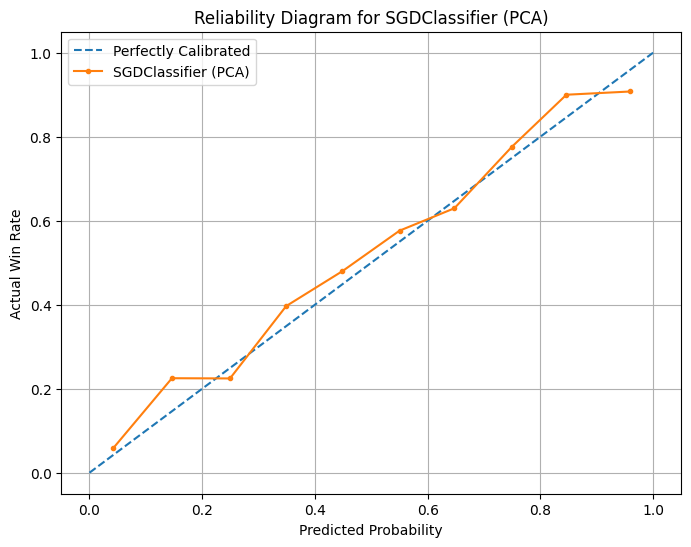

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get raw probabilities for SGDClassifier (pca_scaled_sgd.pkl)
sgd_probs_test = sgd.predict_proba(X_test_scaled)[:, 1]

# Calculate calibration curve for SGD
prob_true_sgd, prob_pred_sgd = calibration_curve(y_test, sgd_probs_test, n_bins=10)

# Plot reliability diagram for SGD
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred_sgd, prob_true_sgd, marker='.', label='SGDClassifier (PCA)')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.title('Reliability Diagram for SGDClassifier (PCA)')
plt.legend()
plt.grid(True)
plt.show()

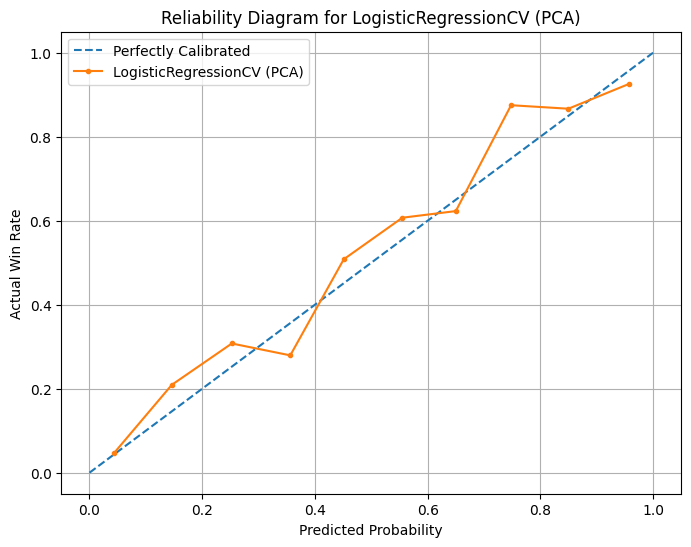

In [ ]:
# Get raw probabilities for LogisticRegressionCV (pca_scaled_log.pkl)
svc_probs_test = svc.predict_proba(X_test_scaled)[:, 1]

# Calculate calibration curve for Logistic Regression
prob_true_log, prob_pred_log = calibration_curve(y_test, svc_probs_test, n_bins=10)

# Plot reliability diagram for Logistic Regression
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred_log, prob_true_log, marker='.', label='LogisticRegressionCV (PCA)')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.title('Reliability Diagram for LogisticRegressionCV (PCA)')
plt.legend()
plt.grid(True)
plt.show()

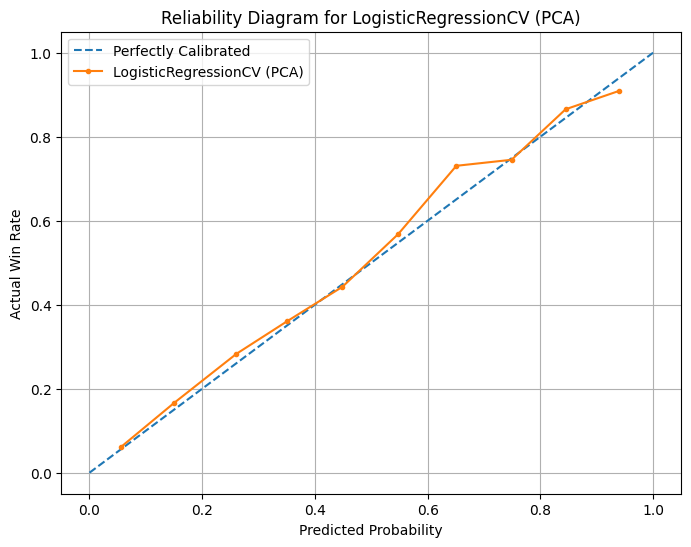

In [ ]:
# Get raw probabilities for LogisticRegressionCV (pca_scaled_log.pkl)
bag_probs_test = bag.predict_proba(X_test_scaled)[:, 1]

# Calculate calibration curve for Logistic Regression
prob_true_log, prob_pred_log = calibration_curve(y_test, bag_probs_test, n_bins=10)

# Plot reliability diagram for Logistic Regression
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred_log, prob_true_log, marker='.', label='LogisticRegressionCV (PCA)')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.title('Reliability Diagram for LogisticRegressionCV (PCA)')
plt.legend()
plt.grid(True)
plt.show()

### bracket and monte carlo init

In [ ]:
class Bracket:

    def __init__(self, round_64: list[tuple[str,str]]):

        self.rounds: dict[int, list[tuple[str, str]]] = dict()
        self.rounds[64] = round_64
        for round in list(2**i for i in range(5,0,-1)):
            self.rounds[round] = list()

In [ ]:
def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    needed_cols: list[str] = ["school_name","srs","sos","ORtg","DRtg","pace","efg", "opp_efg",
                              "orb_pct", "opp_orb_pct", "tov_pct", "opp_tov_pct", "ft_fga",
                              "opp_ft_fga", "3par"]

    # scaler = StandardScaler()
    db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
    for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
        db_used[f"net_{col}_team1"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
        db_used[f"net_{col}_team2"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
        db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]

    # for augmented section
    mirrored = -db_used.iloc[:,:-12].copy()
    for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
        mirrored[f"net_{col}_team1"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
        mirrored[f"net_{col}_team2"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
        mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    X_scaled = scaler.transform(X)
    db_next = db26.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        # c1 = 0.4402
        # c2 = 0.3995
        # c3 = 0.1603

        # nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()
        # gb_probs = gb.predict_proba(X)[:,-1]
        # log_probs = log.predict_proba(X)[:,-1]

        # vote_pred = (c1 * nn_probs + c2 * gb_probs + c3 * log_probs)

        vote_pred = nn.predict_proba(torch.tensor(X_scaled, dtype = torch.float32))[:,-1,0]

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
            # list(zip(db25["team1"], db25["team2"]))
        # bracket.rounds[round//2] = list((db_eval["winner"].values[::2][i],
        #                                 db_eval["winner"].values[1::2][i]) for i in range(round//4))
        bracket.rounds[round//2] = list(db_eval["winner"].values)
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)
                # bracket.rounds[round].append((t1,t2))

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            # print('here')
            db_next = pd.merge(
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "school_name_team1"),
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "school_name_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["school_name_team1", "school_name_team2"], axis = 1)

            # print(db_next.columns)

            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            # comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            # db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            # for comp in comps:
            #     db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            # db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            # # adding net stats
            # db_used["net_efg"] = db_next["efg_team1"] - db_next["opp_efg_team2"]
            # db_used["net_tov_pct"] = db_next["tov_pct_team1"] - db_next["opp_tov_pct_team2"]

            # mirrored = -db_used.iloc[:,:-2].copy()
            # mirrored["net_efg"] = db_next["efg_team2"] - db_next["opp_efg_team1"]
            # mirrored["net_tov_pct"] = db_next["tov_pct_team2"] - db_next["opp_tov_pct_team1"]

            # db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()
            for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
                db_used[f"net_{col}_team1"] = db_next[f"{col}_team1"] - db_next[f"opp_{col}_team2"]
                db_used[f"net_{col}_team2"] = db_next[f"{col}_team2"] - db_next[f"opp_{col}_team1"]
                db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]

            # for augmented section
            mirrored = -db_used.iloc[:,:-12].copy()
            for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
                mirrored[f"net_{col}_team1"] = db_next[f"{col}_team2"] - db_next[f"opp_{col}_team1"]
                mirrored[f"net_{col}_team2"] = db_next[f"{col}_team1"] - db_next[f"opp_{col}_team2"]
                mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]

            # print(db_used.columns)

            X = np.vstack([np.array(db_used), np.array(mirrored)])

            X_scaled = scaler.transform(X)

    for team in teamstats26["school_name"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            # bracket.rounds[2].append(team)
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
                bracket.rounds[1] = team
            # else:
            #     bracket.rounds[2].append(team)
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes, bracket

### looping

In [ ]:
bracket = Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)])
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 1
i: int = 0
start = time.time()

finishes, bracket = MC_MM(finishes, bracket)

brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time.time()
for id in range(1):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in bracket.rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(bracket.rounds[round][::2], bracket.rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]

In [ ]:
import time

In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 10000
i: int = 0
start = time.time()

brackets = list(Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)]) for _ in range(n))
for brack in brackets:
    finishes, brack = MC_MM(finishes, brack)
    i += 1
    if (i + 1) % 500 == 0:
        print(f"Bracket {i}: {(time.time() - start)/60}")

Bracket 499: 3.000447328885396
Bracket 999: 5.6518030722936
Bracket 1499: 8.264241103331248
Bracket 1999: 10.982183547814687
Bracket 2499: 13.615971887111664
Bracket 2999: 16.280270127455392
Bracket 3499: 18.915401562054953
Bracket 3999: 21.557782061894734
Bracket 4499: 24.23960547844569
Bracket 4999: 26.888785604635874
Bracket 5499: 29.522495897610984
Bracket 5999: 32.2034285902977
Bracket 6499: 34.83369021018346
Bracket 6999: 37.4812119325002
Bracket 7499: 40.13177132606506
Bracket 7999: 42.76568933725357
Bracket 8499: 45.388248495260875
Bracket 8999: 48.011201004187264
Bracket 9499: 50.63077766100566
Bracket 9999: 53.270366954803464


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time.time()
for id in range(10000):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in brackets[id].rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(brackets[id].rounds[round][::2], brackets[id].rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]
    if (id + 1) % 1000 == 0:
        print(f"Bracket {id + 1}: {(time.time() - start)/60}")
        brackets_table.to_csv(f"brackets{id + 1}.csv")
        # files.download(f"brackets{id + 1}.csv")
        brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])

Bracket 1000: 2.713113776842753
Bracket 2000: 5.660684474309286
Bracket 3000: 8.480804085731506
Bracket 4000: 11.166901942094167
Bracket 5000: 13.859309188524882
Bracket 6000: 16.548033134142557
Bracket 7000: 19.379915873209637
Bracket 8000: 22.139675358931225
Bracket 9000: 24.922116708755492
Bracket 10000: 27.62113329966863


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
for b in range(1000, 11000, 1000):
    brackets_table = pd.concat([brackets_table,
                                pd.read_csv(f"brackets{b}.csv").drop("Unnamed: 0", axis = 1)])

In [ ]:
brackets_table.to_csv("brackets23.csv", index = False)

## pca sim

In [ ]:
X = np.vstack([np.array(db_used), np.array(mirrored)])

from sklearn.decomposition import PCA

with open('scaler_plus_PCA_fitted.pkl', 'rb') as f:
    pca = pickle.load(f)

X_pca = pca.transform(X)

### old

In [ ]:
NN = Model(12, n_layers = 1, hidden_dim=8, dropout = 0.2)

NN.load_state_dict(torch.load("pca_mod12.pth"))

NN.eval()

Model(
  (layers): ModuleList(
    (0): Linear(in_features=12, out_features=8, bias=False)
    (1): Linear(in_features=8, out_features=8, bias=False)
  )
  (bn_layers): ModuleList(
    (0-1): 2 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

NN weight = .248\
Ada weight = .059\
Log weight = .248\
Sgd weight = .446

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier

with open('pca_scaled_ada.pkl', 'rb') as f:
    ada = pickle.load(f)

with open("pca_scaled_log.pkl", "rb") as f:
    log = pickle.load(f)

with open("pca_scaled_sgd.pkl", "rb") as f:
    sgd = pickle.load(f)

In [ ]:
c1 = 0.248
c2 = 0.059
c3 = 0.248
c4 = 0.446

nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()
ada_probs = ada.predict_proba(X)[:,-1]
log_probs = log.predict_proba(X)[:,-1]
sgd_probs = sgd.predict_proba(X)[:,-1]

vote_pred = (c1 * nn_probs + c2 * ada_probs + c3 * log_probs + c4 * sgd_probs)

### r64

In [ ]:
from sklearn.ensemble import BaggingClassifier

with open("bag_pca_scaled_12.pkl", "rb") as f:
    bag = pickle.load(f)

vote_pred = bag.predict_proba(X_pca)[:,-1]

In [ ]:
with open("nn_pca_scaled_12.pkl", "rb") as f:
    nn = pickle.load(f)

vote_pred = nn.predict_proba(torch.tensor(X_pca, dtype = torch.float32))[:,-1]

# with open("log_pca_scaled_12.pkl", "rb") as f:
#     log = pickle.load(f)

# with open("sgd_pca_scaled_12.pkl", "rb") as f:
#     sgd = pickle.load(f)

# vote_pred = lnn.predict_proba(X_pca)[:,-1]

In [ ]:
db_eval = pd.DataFrame(np.vstack([db26.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db26.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
db_eval1 = db_eval[:len(db_eval)//2].reset_index().copy()
db_eval2 = db_eval[-len(db_eval)//2:].reset_index().copy()
db_eval["avg_team1_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:len(db_eval)//2].copy().drop("team1_pred", axis = 1)
db_eval.to_csv("r64preds_pca.csv", index = False)
db_eval

,team1,team2,team1_seed,team2_seed,avg_team1_pred
0,Duke,Siena,1,16,0.972838
1,Ohio State,TCU,8,9,0.570873
2,St. John's (NY),Northern Iowa,5,12,0.806689
3,Kansas,California Baptist,4,13,0.878041
4,Louisville,South Florida,6,11,0.716910
5,Michigan State,North Dakota State,3,14,0.895151
6,UCLA,UCF,7,10,0.648441
7,UConn,Furman,2,15,0.912165
8,Florida,Prairie View A&M,1,16,0.965331
9,Clemson,Iowa,8,9,0.451997


### bracket MC init

In [ ]:
class Bracket:

    def __init__(self, round_64: list[tuple[str,str]]):

        self.rounds: dict[int, list[tuple[str, str]]] = dict()
        self.rounds[64] = round_64
        for round in list(2**i for i in range(5,0,-1)):
            self.rounds[round] = list()

In [ ]:
def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    needed_cols: list[str] = ["school_name","srs","sos","ORtg","DRtg","pace","efg", "opp_efg",
                              "orb_pct", "opp_orb_pct", "tov_pct", "opp_tov_pct", "ft_fga",
                              "opp_ft_fga", "3par"]

    # scaler = StandardScaler()
    db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
    for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
        db_used[f"net_{col}_team1"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
        db_used[f"net_{col}_team2"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
        db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]

    # for augmented section
    mirrored = -db_used.iloc[:,:-12].copy()
    for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
        mirrored[f"net_{col}_team1"] = db26[f"{col}_team2"] - db26[f"opp_{col}_team1"]
        mirrored[f"net_{col}_team2"] = db26[f"{col}_team1"] - db26[f"opp_{col}_team2"]
        mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    X_pca = pca.transform(X)
    db_next = db26.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        # c1 = 0.248
        # c2 = 0.059
        # c3 = 0.248
        # c4 = 0.446

        # nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()
        # ada_probs = ada.predict_proba(X)[:,-1]
        # log_probs = log.predict_proba(X)[:,-1]
        # sgd_probs = sgd.predict_proba(X)[:,-1]

        # vote_pred = (c1 * nn_probs + c2 * ada_probs + c3 * log_probs + c4 * sgd_probs)

        vote_pred = nn.predict_proba(torch.tensor(X_pca, dtype = torch.float32))[:,-1]

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
            # list(zip(db25["team1"], db25["team2"]))
        # bracket.rounds[round//2] = list((db_eval["winner"].values[::2][i],
        #                                 db_eval["winner"].values[1::2][i]) for i in range(round//4))
        bracket.rounds[round//2] = list(db_eval["winner"].values)
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)
                # bracket.rounds[round].append((t1,t2))

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            # print('here')
            db_next = pd.merge(
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "school_name_team1"),
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "school_name_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["school_name_team1", "school_name_team2"], axis = 1)

            # print(db_next.columns)

            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            # comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            # db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            # for comp in comps:
            #     db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            # db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            # # adding net stats
            # db_used["net_efg"] = db_next["efg_team1"] - db_next["opp_efg_team2"]
            # db_used["net_tov_pct"] = db_next["tov_pct_team1"] - db_next["opp_tov_pct_team2"]

            # mirrored = -db_used.iloc[:,:-2].copy()
            # mirrored["net_efg"] = db_next["efg_team2"] - db_next["opp_efg_team1"]
            # mirrored["net_tov_pct"] = db_next["tov_pct_team2"] - db_next["opp_tov_pct_team1"]

            # db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()
            for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
                db_used[f"net_{col}_team1"] = db_next[f"{col}_team1"] - db_next[f"opp_{col}_team2"]
                db_used[f"net_{col}_team2"] = db_next[f"{col}_team2"] - db_next[f"opp_{col}_team1"]
                db_used[f"net_{col}_spread"] = db_used[f"net_{col}_team1"] - db_used[f"net_{col}_team2"]

            # for augmented section
            mirrored = -db_used.iloc[:,:-12].copy()
            for col in ["efg", "orb_pct", "tov_pct", "ft_fga"]:
                mirrored[f"net_{col}_team1"] = db_next[f"{col}_team2"] - db_next[f"opp_{col}_team1"]
                mirrored[f"net_{col}_team2"] = db_next[f"{col}_team1"] - db_next[f"opp_{col}_team2"]
                mirrored[f"net_{col}_spread"] = mirrored[f"net_{col}_team1"] - mirrored[f"net_{col}_team2"]

            # print(db_used.columns)

            X = np.vstack([np.array(db_used), np.array(mirrored)])

            X_pca = pca.transform(X)

    for team in teamstats26["school_name"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            # bracket.rounds[2].append(team)
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
                bracket.rounds[1] = team
            # else:
            #     bracket.rounds[2].append(team)
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes, bracket

### looping

In [ ]:
bracket = Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)])
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 1
i: int = 0
start = time.time()

finishes, bracket = MC_MM(finishes, bracket)

brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time.time()
for id in range(1):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in bracket.rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(bracket.rounds[round][::2], bracket.rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]

In [ ]:
brackets_table

,id,round,seed1,team1,seed2,team2,winner
0,0,64,1,Duke,16,Siena,Duke
1,0,64,8,Ohio State,9,TCU,TCU
2,0,64,5,St. John's (NY),12,Northern Iowa,St. John's (NY)
3,0,64,4,Kansas,13,California Baptist,Kansas
4,0,64,6,Louisville,11,South Florida,Louisville
...,...,...,...,...,...,...,...
58,0,8,1,Arizona,3,Gonzaga,Arizona
59,0,8,1,Michigan,2,Iowa State,Michigan
60,0,4,10,UCF,1,Florida,Florida
61,0,4,1,Arizona,1,Michigan,Michigan


In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 10000
i: int = 0
start = time.time()

brackets = list(Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)]) for _ in range(n))
for brack in brackets:
    finishes, brack = MC_MM(finishes, brack)
    i += 1
    if (i + 1) % 500 == 0:
        print(f"Bracket {i}: {(time.time() - start)/60}")

Bracket 499: 2.755740761756897
Bracket 999: 5.547441999117534
Bracket 1499: 8.34944563706716
Bracket 1999: 11.090261542797089
Bracket 2499: 13.810502862930297
Bracket 2999: 16.506778422991434
Bracket 3499: 19.210872304439544
Bracket 3999: 21.94752269188563
Bracket 4499: 24.68050141731898
Bracket 4999: 27.376576030254363
Bracket 5499: 30.072612885634104
Bracket 5999: 32.77029254436493
Bracket 6499: 35.48930200735728
Bracket 6999: 38.20596689383189
Bracket 7499: 40.92670535246531
Bracket 7999: 43.6241609454155
Bracket 8499: 46.31277335882187
Bracket 8999: 48.99411038955053
Bracket 9499: 51.67411386966705
Bracket 9999: 55.22982052961985


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time.time()
for id in range(10000):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in brackets[id].rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(brackets[id].rounds[round][::2], brackets[id].rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]
    if (id + 1) % 1000 == 0:
        print(f"Bracket {id + 1}: {(time.time() - start)/60}")
        brackets_table.to_csv(f"brackets{id + 1}_pca.csv")
        # files.download(f"brackets{id + 1}.csv")
        brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])

Bracket 1000: 2.8028790752092996
Bracket 2000: 5.551496390501658
Bracket 3000: 8.227269581953685
Bracket 4000: 10.960050241152446
Bracket 5000: 13.723557154337565
Bracket 6000: 16.45284330844879
Bracket 7000: 19.236747380097707
Bracket 8000: 22.039903140068056
Bracket 9000: 24.820709721247354
Bracket 10000: 27.592311402161915


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
for b in range(1000, 11000, 1000):
    brackets_table = pd.concat([brackets_table,
                                pd.read_csv(f"brackets{b}_pca.csv").drop("Unnamed: 0", axis = 1)])

brackets_table.to_csv("brackets23_pca.csv", index = False)